In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer, RobustScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, classification_report

In [ ]:
df = pd.read_csv('D:\dummyML\data\polder_data_fix.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\UsHER\AppData\Local\Temp\ipykernel_8528\325939391.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('D:\dummyML\data\polder_data_fix.csv')


,timestamp,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,Pump1,Pump2,Pump3,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,pintu,pump_on,status_banjir
0,2025-06-09 00:00:00,0.466032,2.389919,1.819317,on,on,off,0.634561,6.569780,12.875024,0.0,0.0,0.0,1.0,0.0
1,2025-06-09 00:02:27,0.470409,2.398388,1.836405,on,on,off,0.629908,6.559635,12.874414,0.0,0.0,0.0,1.0,0.0
2,2025-06-09 00:07:27,0.479342,2.415673,1.871278,on,on,off,0.620411,6.538929,12.873169,0.0,0.0,0.0,1.0,0.0
3,2025-06-09 00:12:27,0.488275,2.432957,1.906150,on,on,off,0.610914,6.518223,12.871923,0.0,0.0,0.0,1.0,0.0
4,2025-06-09 00:17:27,0.497208,2.450241,1.941023,on,on,off,0.601418,6.497517,12.870678,0.0,0.0,0.0,1.0,0.0


In [76]:
df_copy = df.copy()
df_copy.head()


,timestamp,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,Pump1,Pump2,Pump3,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,pintu,pump_on,status_banjir
0,2025-06-09 00:00:00,0.466032,2.389919,1.819317,on,on,off,0.634561,6.569780,12.875024,0.0,0.0,0.0,1.0,0.0
1,2025-06-09 00:02:27,0.470409,2.398388,1.836405,on,on,off,0.629908,6.559635,12.874414,0.0,0.0,0.0,1.0,0.0
2,2025-06-09 00:07:27,0.479342,2.415673,1.871278,on,on,off,0.620411,6.538929,12.873169,0.0,0.0,0.0,1.0,0.0
3,2025-06-09 00:12:27,0.488275,2.432957,1.906150,on,on,off,0.610914,6.518223,12.871923,0.0,0.0,0.0,1.0,0.0
4,2025-06-09 00:17:27,0.497208,2.450241,1.941023,on,on,off,0.601418,6.497517,12.870678,0.0,0.0,0.0,1.0,0.0


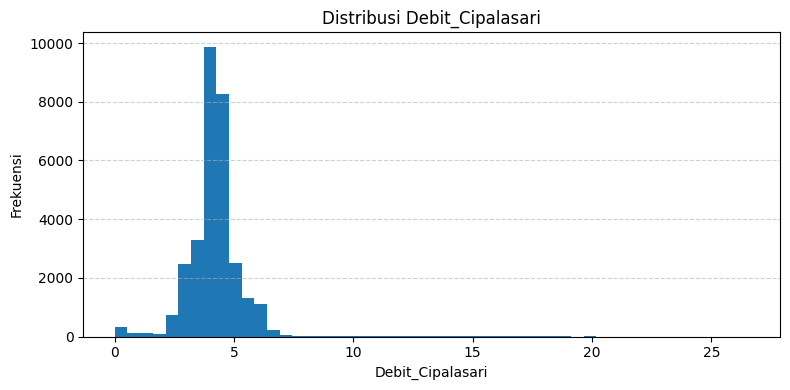

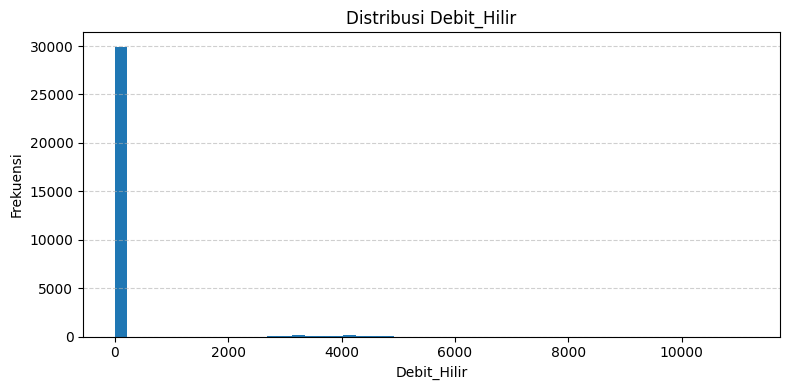

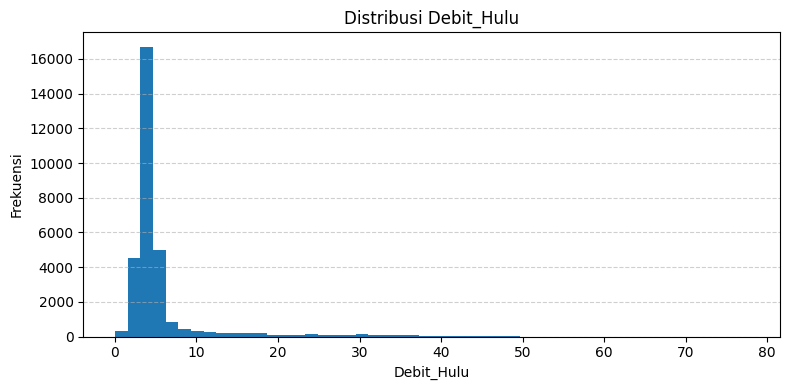

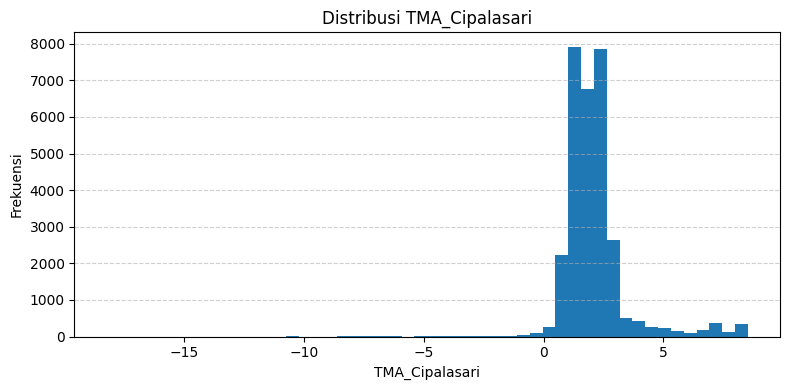

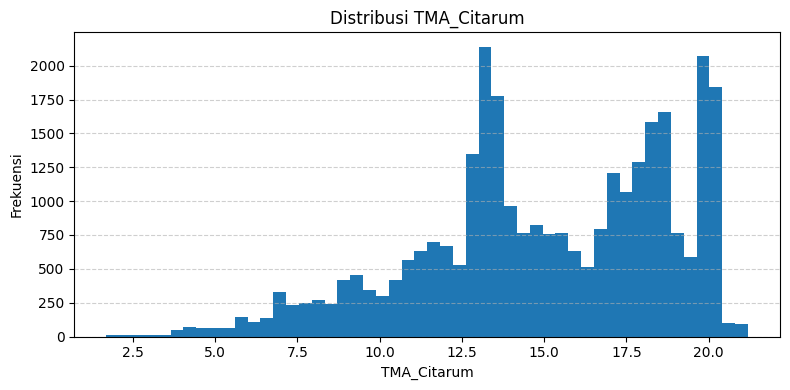

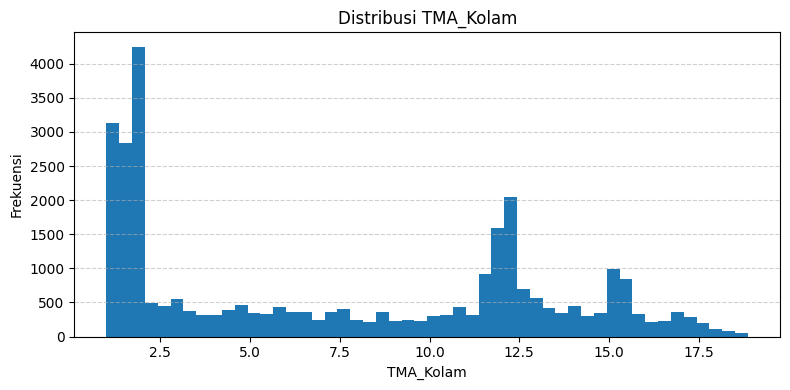

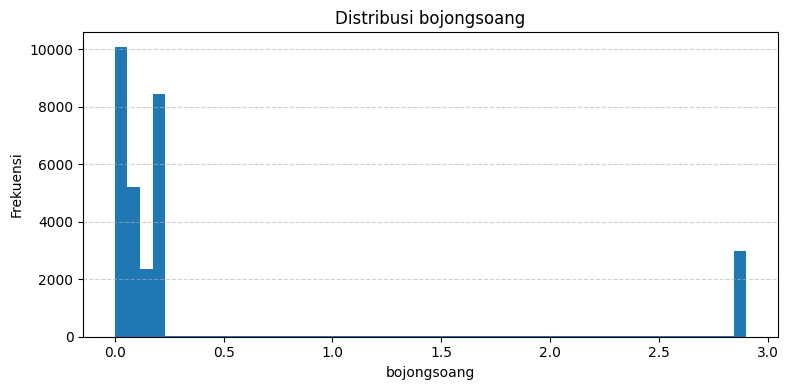

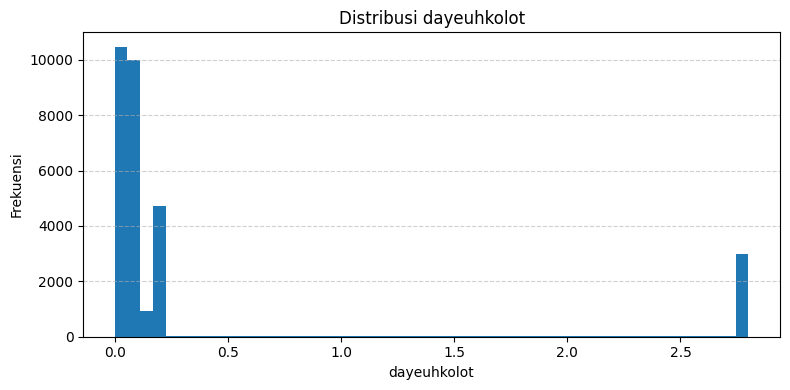

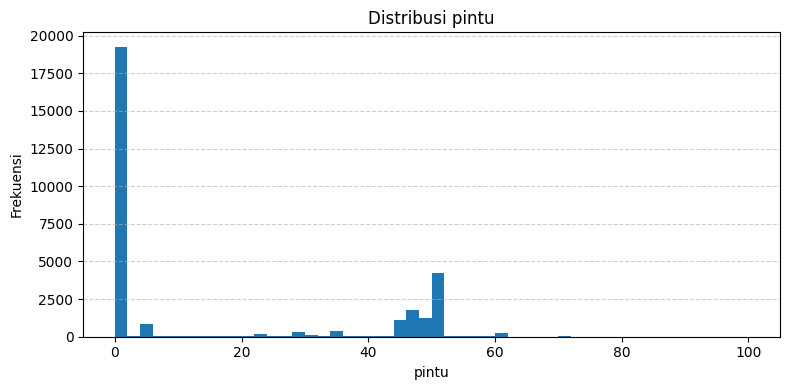

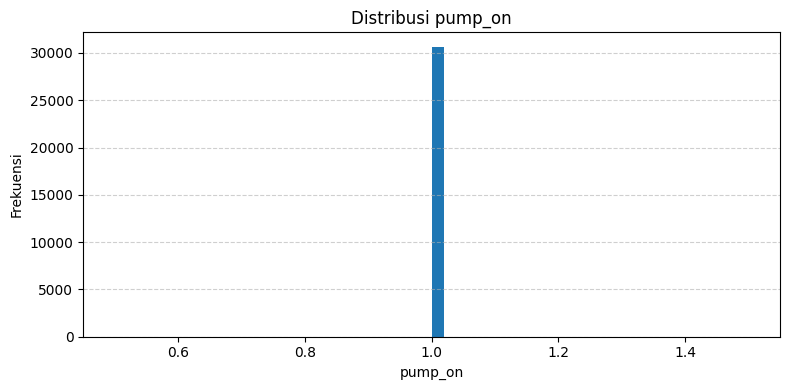

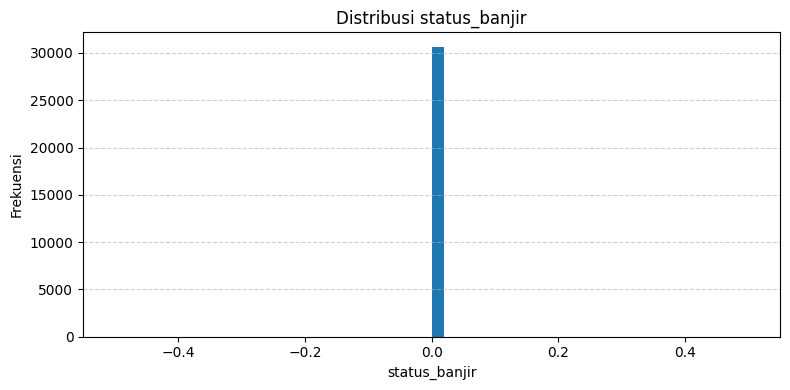

In [77]:
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


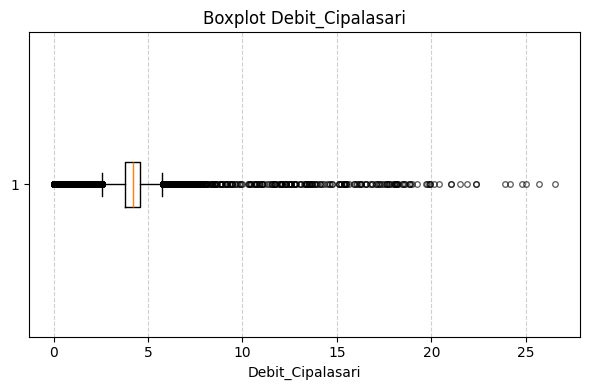

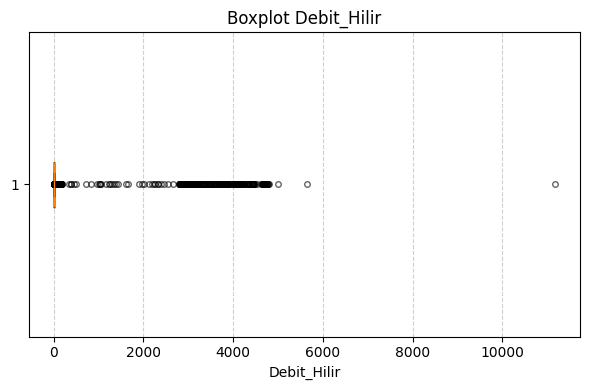

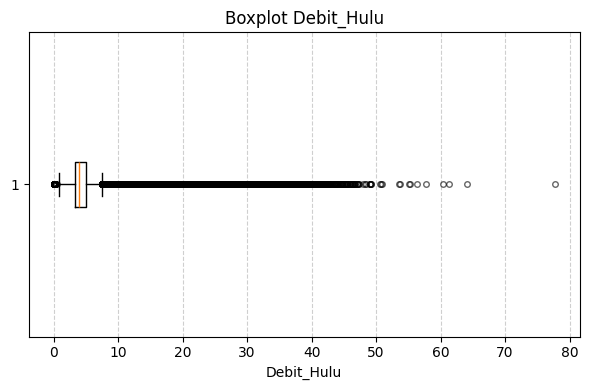

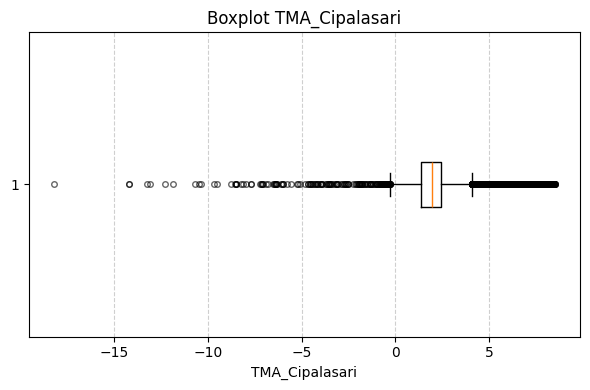

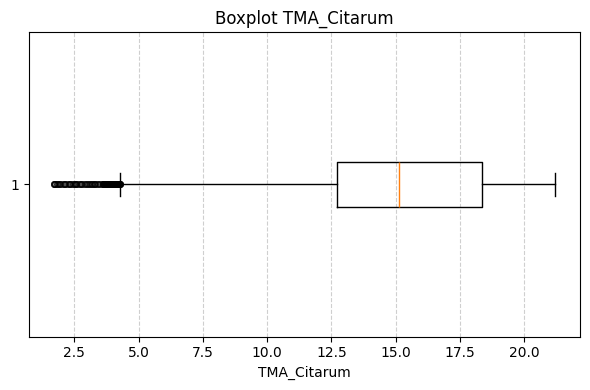

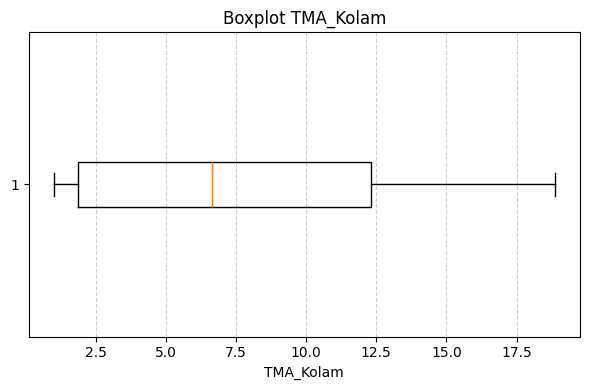

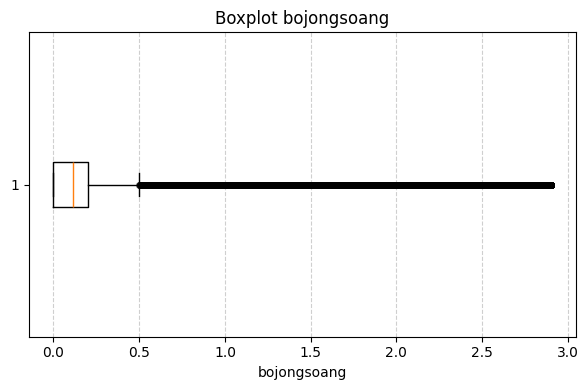

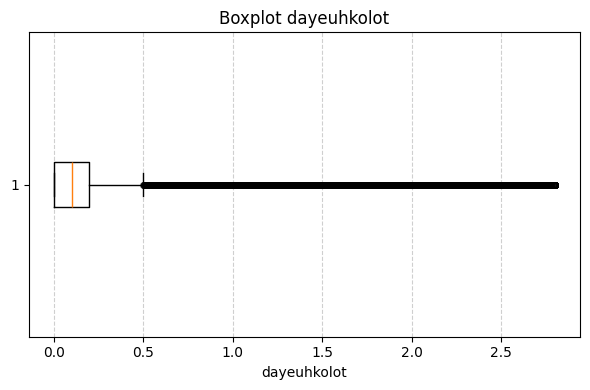

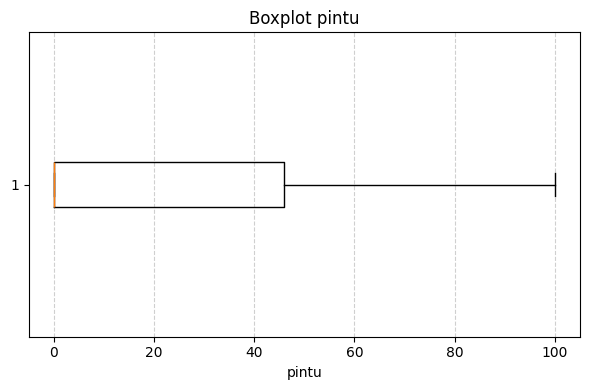

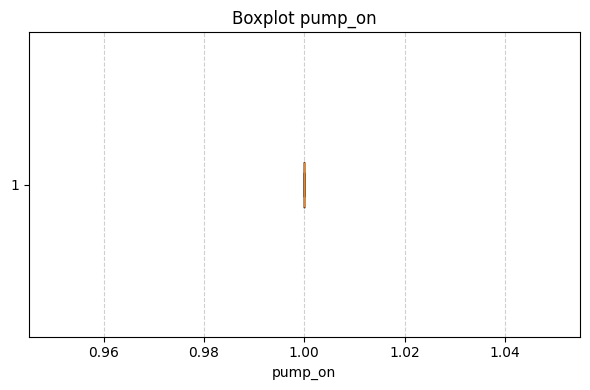

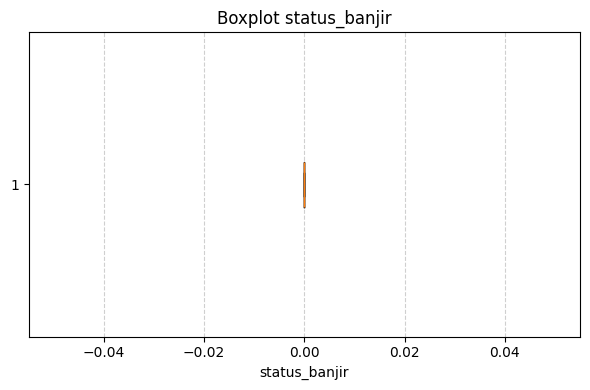

In [78]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna(), vert=False, showfliers=True,
                flierprops=dict(marker='o', markersize=4, alpha=0.6))
    plt.title(f'Boxplot {col}')
    plt.xlabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Debit_Cipalasari_norm: skew=-0.6232, kurtosis=3.4655


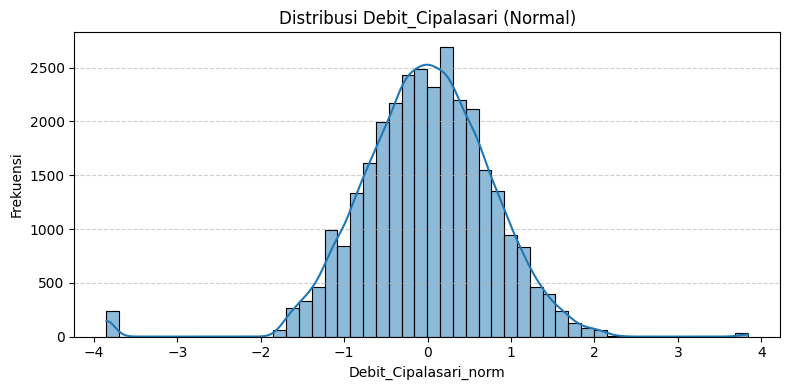

Debit_Hilir_norm: skew=-0.3928, kurtosis=2.6779


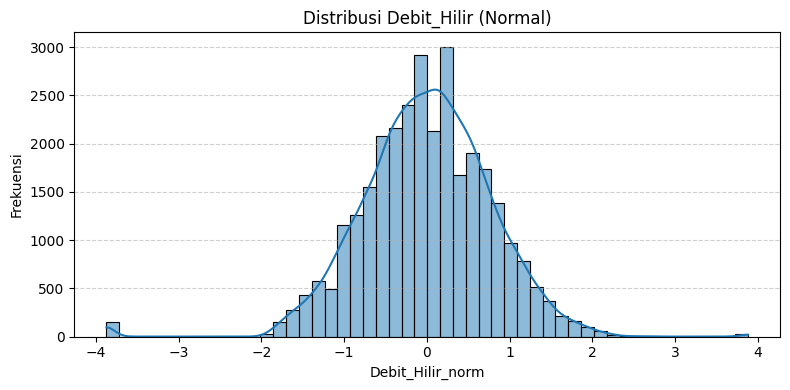

Debit_Hulu_norm: skew=-0.5652, kurtosis=3.2284


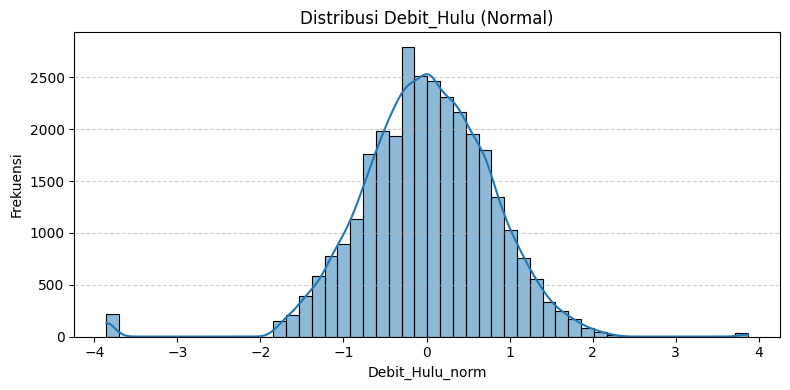

In [79]:
qt = QuantileTransformer(output_distribution='normal', random_state=42)
rs = RobustScaler()

# --- 1. Debit Cipalasari ---
df_copy['Debit_Cipalasari_log'] = np.log1p(df_copy['Debit_Cipalasari'])
low, high = df_copy['Debit_Cipalasari_log'].quantile([0.001, 0.999])
df_copy['Debit_Cipalasari_clip'] = df_copy['Debit_Cipalasari_log'].clip(low, high)
th = df_copy['Debit_Cipalasari'].quantile(0.95)
df_copy['high_flow_flag'] = (df_copy['Debit_Cipalasari'] > th).astype(int)
df_copy['Debit_Cipalasari_qt'] = qt.fit_transform(df_copy[['Debit_Cipalasari_clip']])
df_copy['Debit_Cipalasari_norm'] = rs.fit_transform(df_copy[['Debit_Cipalasari_qt']])
print(f"Debit_Cipalasari_norm: skew={df_copy['Debit_Cipalasari_norm'].skew():.4f}, "
      f"kurtosis={df_copy['Debit_Cipalasari_norm'].kurtosis():.4f}")
plt.figure(figsize=(8,4))
sns.histplot(df_copy['Debit_Cipalasari_norm'], bins=50, kde=True)
plt.title('Distribusi Debit_Cipalasari (Normal)')
plt.xlabel('Debit_Cipalasari_norm')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 2. Debit Hilir ---
df_copy['Debit_Hilir_log'] = np.log1p(df_copy['Debit_Hilir'])
low, high = df_copy['Debit_Hilir_log'].quantile([0.001, 0.999])
df_copy['Debit_Hilir_clip'] = df_copy['Debit_Hilir_log'].clip(low, high)
th = df_copy['Debit_Hilir'].quantile(0.95)
df_copy['high_flow_hilir'] = (df_copy['Debit_Hilir'] > th).astype(int)
df_copy['Debit_Hilir_qt'] = qt.fit_transform(df_copy[['Debit_Hilir_clip']])
df_copy['Debit_Hilir_norm'] = rs.fit_transform(df_copy[['Debit_Hilir_qt']])
print(f"Debit_Hilir_norm: skew={df_copy['Debit_Hilir_norm'].skew():.4f}, "
      f"kurtosis={df_copy['Debit_Hilir_norm'].kurtosis():.4f}")
plt.figure(figsize=(8,4))
sns.histplot(df_copy['Debit_Hilir_norm'], bins=50, kde=True)
plt.title('Distribusi Debit_Hilir (Normal)')
plt.xlabel('Debit_Hilir_norm')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 3. Debit Hulu ---
df_copy['Debit_Hulu_log'] = np.log1p(df_copy['Debit_Hulu'])
low, high = df_copy['Debit_Hulu_log'].quantile([0.001, 0.999])
df_copy['Debit_Hulu_clip'] = df_copy['Debit_Hulu_log'].clip(low, high)
th = df_copy['Debit_Hulu'].quantile(0.95)
df_copy['high_flow_hulu'] = (df_copy['Debit_Hulu'] > th).astype(int)
df_copy['Debit_Hulu_qt'] = qt.fit_transform(df_copy[['Debit_Hulu_clip']])
df_copy['Debit_Hulu_norm'] = rs.fit_transform(df_copy[['Debit_Hulu_qt']])
print(f"Debit_Hulu_norm: skew={df_copy['Debit_Hulu_norm'].skew():.4f}, "
      f"kurtosis={df_copy['Debit_Hulu_norm'].kurtosis():.4f}")
plt.figure(figsize=(8,4))
sns.histplot(df_copy['Debit_Hulu_norm'], bins=50, kde=True)
plt.title('Distribusi Debit_Hulu (Normal)')
plt.xlabel('Debit_Hulu_norm')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [80]:
df_copy.head()

,timestamp,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,Pump1,Pump2,Pump3,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,...,Debit_Hilir_log,Debit_Hilir_clip,high_flow_hilir,Debit_Hilir_qt,Debit_Hilir_norm,Debit_Hulu_log,Debit_Hulu_clip,high_flow_hulu,Debit_Hulu_qt,Debit_Hulu_norm
0,2025-06-09 00:00:00,0.466032,2.389919,1.819317,on,on,off,0.634561,6.569780,12.875024,...,1.220806,1.220806,0,-2.321682,-1.727226,1.036495,1.036495,0,-2.293272,-1.695403
1,2025-06-09 00:02:27,0.470409,2.398388,1.836405,on,on,off,0.629908,6.559635,12.874414,...,1.223301,1.223301,0,-2.320452,-1.726308,1.042537,1.042537,0,-2.290062,-1.693017
2,2025-06-09 00:07:27,0.479342,2.415673,1.871278,on,on,off,0.620411,6.538929,12.873169,...,1.228374,1.228374,0,-2.317962,-1.724451,1.054757,1.054757,0,-2.264140,-1.673759
3,2025-06-09 00:12:27,0.488275,2.432957,1.906150,on,on,off,0.610914,6.518223,12.871923,...,1.233422,1.233422,0,-2.315499,-1.722613,1.066829,1.066829,0,-2.228444,-1.647239
4,2025-06-09 00:17:27,0.497208,2.450241,1.941023,on,on,off,0.601418,6.497517,12.870678,...,1.238444,1.238444,0,-2.313062,-1.720795,1.078758,1.078758,0,-2.205577,-1.630250


Skewness: 0.005161027730337363
Kurtosis: 5.40140160321911


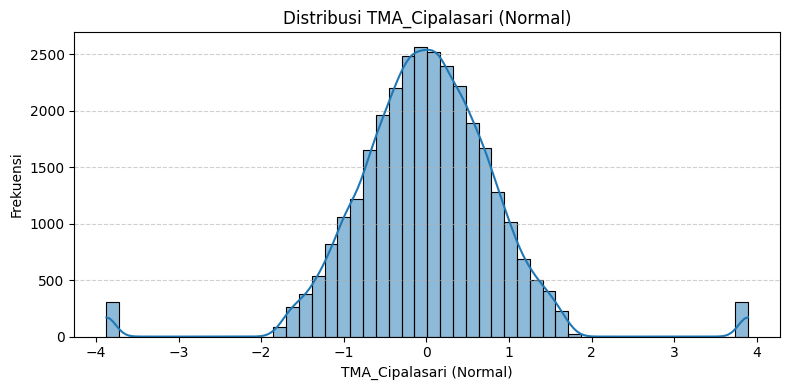

In [81]:
pt = PowerTransformer(method='yeo-johnson', standardize=False)
df_copy['TMA_Cip_pt'] = pt.fit_transform(df_copy[['TMA_Cipalasari']])

# 3. Winsorize pada persentil 1%–99% untuk buang noise ekstrem
low, high = df_copy['TMA_Cip_pt'].quantile([0.01, 0.99])
df_copy['TMA_Cip_clip'] = df_copy['TMA_Cip_pt'].clip(low, high)

# 4. Flag “high tide” (>95-persentil asli)
thr = df_copy['TMA_Cipalasari'].quantile(0.95)
df_copy['high_tide_flag'] = (df_copy['TMA_Cipalasari'] > thr).astype(int)

# 5. QuantileTransformer → distribusi Gaussian
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_copy['TMA_Cip_qt'] = qt.fit_transform(df_copy[['TMA_Cip_clip']])

# 6. RobustScaler → median=0, IQR=1
rs = RobustScaler()
df_copy['TMA_Cip_norm'] = rs.fit_transform(df_copy[['TMA_Cip_qt']])

# (Opsional) Cek skewness & kurtosis
from scipy.stats import skew, kurtosis
print("Skewness:", skew(df_copy['TMA_Cip_norm']))
print("Kurtosis:", kurtosis(df_copy['TMA_Cip_norm']))

plt.figure(figsize=(8, 4))
sns.histplot(df_copy['TMA_Cip_norm'], bins=50, kde=True)
plt.title('Distribusi TMA_Cipalasari (Normal)')
plt.xlabel('TMA_Cipalasari (Normal)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Skewness: 0.2463374718382723
Kurtosis: 5.742268178632703


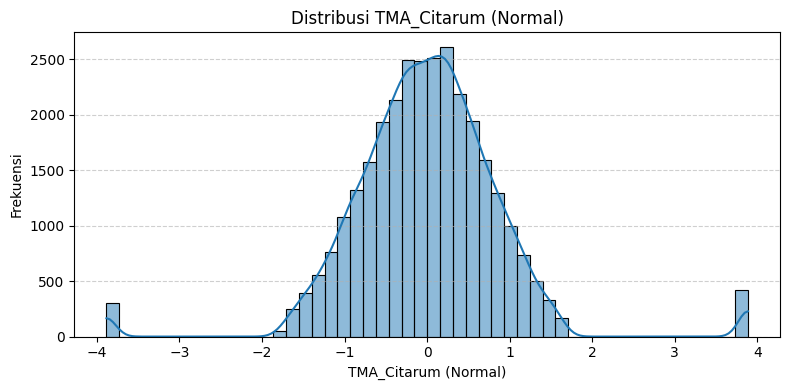

In [82]:
pt = PowerTransformer(method='yeo-johnson', standardize=False)
df_copy['TMA_Cit_pt'] = pt.fit_transform(df_copy[['TMA_Citarum']])

# 3. Winsorize di persentil 1%–99% untuk buang noise ekstrem
low, high = df_copy['TMA_Cit_pt'].quantile([0.01, 0.99])
df_copy['TMA_Cit_clip'] = df_copy['TMA_Cit_pt'].clip(low, high)

# 4. Indikator “high tide” >95-persentil asli
thr_cit = df_copy['TMA_Citarum'].quantile(0.95)
df_copy['high_tide_cit'] = (df_copy['TMA_Citarum'] > thr_cit).astype(int)

# 5. QuantileTransformer → paksa distribusi Gaussian
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_copy['TMA_Cit_qt'] = qt.fit_transform(df_copy[['TMA_Cit_clip']])

# 6. RobustScaler → median=0, IQR=1
rs = RobustScaler()
df_copy['TMA_Cit_norm'] = rs.fit_transform(df_copy[['TMA_Cit_qt']])

# 7. Verifikasi skewness & kurtosis
print("Skewness:", skew(df_copy['TMA_Cit_norm']))
print("Kurtosis:", kurtosis(df_copy['TMA_Cit_norm']))

plt.figure(figsize=(8, 4))
sns.histplot(df_copy['TMA_Cit_norm'], bins=50, kde=True)
plt.title('Distribusi TMA_Citarum (Normal)')
plt.xlabel('TMA_Citarum (Normal)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Skewness: -0.0766325079465525
Kurtosis: 5.670925340787665


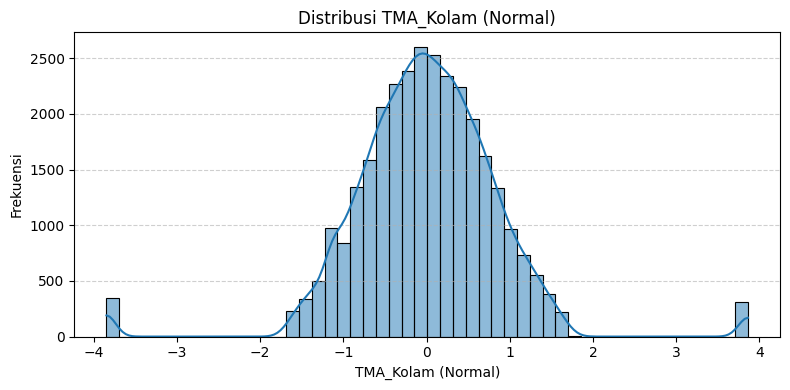

In [83]:
pt = PowerTransformer(method='yeo-johnson', standardize=False)
df_copy['TMA_Kolam_pt'] = pt.fit_transform(df_copy[['TMA_Kolam']])

# 3. Winsorize (clip) pada persentil 1%–99% untuk buang noise ekstrem
low, high = df_copy['TMA_Kolam_pt'].quantile([0.01, 0.99])
df_copy['TMA_Kolam_clip'] = df_copy['TMA_Kolam_pt'].clip(low, high)

# 4. Indikator “high water” (>95-persentil asli)
thr_kolam = df_copy['TMA_Kolam'].quantile(0.95)
df_copy['high_water_flag'] = (df_copy['TMA_Kolam'] > thr_kolam).astype(int)

# 5. QuantileTransformer → memaksa distribusi mendekati Gaussian
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_copy['TMA_Kolam_qt'] = qt.fit_transform(df_copy[['TMA_Kolam_clip']])

# 6. RobustScaler → median=0, IQR=1, tahan outlier tersisa
rs = RobustScaler()
df_copy['TMA_Kolam_norm'] = rs.fit_transform(df_copy[['TMA_Kolam_qt']])

# 7. Cek skewness & kurtosis pasca‐transformasi
print("Skewness:", skew(df_copy['TMA_Kolam_norm']))
print("Kurtosis:", kurtosis(df_copy['TMA_Kolam_norm']))

plt.figure(figsize=(8, 4))
sns.histplot(df_copy['TMA_Kolam_norm'], bins=50, kde=True)
plt.title('Distribusi TMA_Kolam (Normal)')
plt.xlabel('TMA_Kolam (Normal)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Skewness: -0.08194453785254652
Kurtosis: -0.47729809375787724


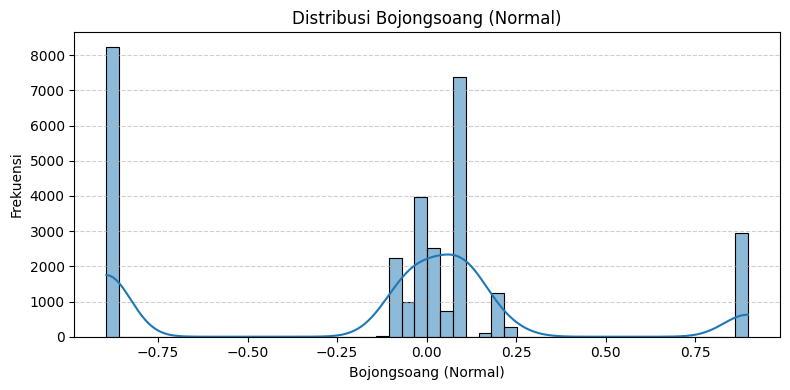

In [84]:
df_copy['bojongsoang_log'] = np.log1p(df_copy['bojongsoang'])

# 2. Winsorize (clip) pada persentil 0.1%–99.9% untuk buang noise ekstrem
lower = df_copy['bojongsoang_log'].quantile(0.001)
upper = df_copy['bojongsoang_log'].quantile(0.999)
df_copy['bojongsoang_clip'] = df_copy['bojongsoang_log'].clip(lower, upper)

# 3. Indikator peristiwa hujan besar (>95 persentil asli)
threshold_bojong = df_copy['bojongsoang'].quantile(0.95)
df_copy['rain_flag_bojong'] = (df_copy['bojongsoang'] > threshold_bojong).astype(int)

# 4. QuantileTransformer → paksa distribusi mendekati Gaussian
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_copy['bojongsoang_qt'] = qt.fit_transform(df_copy[['bojongsoang_clip']])

# 5. RobustScaler → skala median=0, IQR=1 (tahan outlier tersisa)
rs = RobustScaler()
df_copy['bojongsoang_norm'] = rs.fit_transform(df_copy[['bojongsoang_qt']])

# 6. Verifikasi skewness & kurtosis pasca‐transformasi
print("Skewness:", skew(df_copy['bojongsoang_norm']))
print("Kurtosis:", kurtosis(df_copy['bojongsoang_norm']))

plt.figure(figsize=(8, 4))
sns.histplot(df_copy['bojongsoang_norm'], bins=50, kde=True)
plt.title('Distribusi Bojongsoang (Normal)')
plt.xlabel('Bojongsoang (Normal)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Skewness: -0.0846266843755107
Kurtosis: -0.4815101785693505


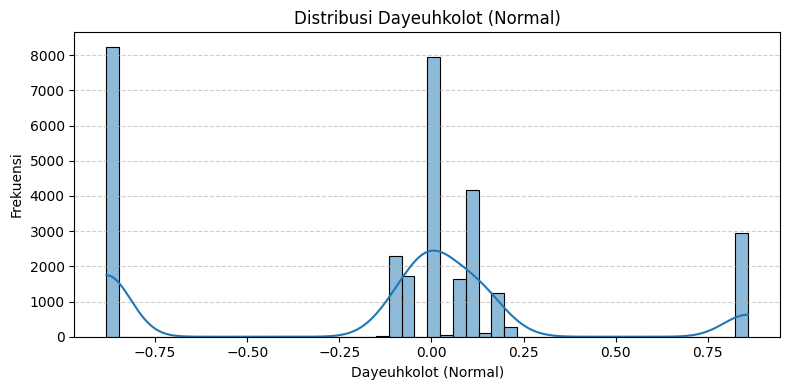

In [85]:
df_copy['dayeuhkolot_log'] = np.log1p(df_copy['dayeuhkolot'])

# 2. Winsorize (clip) pada persentil 0.1%–99.9%
lower = df_copy['dayeuhkolot_log'].quantile(0.001)
upper = df_copy['dayeuhkolot_log'].quantile(0.999)
df_copy['dayeuhkolot_clip'] = df_copy['dayeuhkolot_log'].clip(lower, upper)

# 3. Indikator peristiwa hujan besar (>95-persentil asli)
thr_day = df_copy['dayeuhkolot'].quantile(0.95)
df_copy['rain_flag_day'] = (df_copy['dayeuhkolot'] > thr_day).astype(int)

# 4. QuantileTransformer → paksa distribusi mendekati Gaussian
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_copy['dayeuhkolot_qt'] = qt.fit_transform(df_copy[['dayeuhkolot_clip']])

# 5. RobustScaler → skala median=0, IQR=1 (tahan outlier sisa)
rs = RobustScaler()
df_copy['dayeuhkolot_norm'] = rs.fit_transform(df_copy[['dayeuhkolot_qt']])

# 6. Verifikasi skewness & kurtosis pasca‐transformasi
print("Skewness:", skew(df_copy['dayeuhkolot_norm']))
print("Kurtosis:", kurtosis(df_copy['dayeuhkolot_norm']))

plt.figure(figsize=(8, 4))
sns.histplot(df_copy['dayeuhkolot_norm'], bins=50, kde=True)
plt.title('Distribusi Dayeuhkolot (Normal)')
plt.xlabel('Dayeuhkolot (Normal)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [86]:
df_copy.drop('timestamp', axis=1, inplace=True)
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,Pump1,Pump2,Pump3,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,...,bojongsoang_log,bojongsoang_clip,rain_flag_bojong,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm
0,0.466032,2.389919,1.819317,on,on,off,0.634561,6.569780,12.875024,0.0,...,0.0,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862
1,0.470409,2.398388,1.836405,on,on,off,0.629908,6.559635,12.874414,0.0,...,0.0,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862
2,0.479342,2.415673,1.871278,on,on,off,0.620411,6.538929,12.873169,0.0,...,0.0,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862
3,0.488275,2.432957,1.906150,on,on,off,0.610914,6.518223,12.871923,0.0,...,0.0,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862
4,0.497208,2.450241,1.941023,on,on,off,0.601418,6.497517,12.870678,0.0,...,0.0,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862


In [87]:
df_copy['pump'] = df_copy[['Pump1', 'Pump2', 'Pump3']].eq('on').sum(axis=1)
df_copy.drop(columns=['Pump1', 'Pump2', 'Pump3'], inplace=True)
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,pintu,pump_on,...,bojongsoang_clip,rain_flag_bojong,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.0,1.0,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.0,1.0,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.0,1.0,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.0,1.0,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.0,1.0,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2


In [88]:
df_copy.drop(columns=['pump_on', 'status_banjir', 'pintu'], inplace=True)
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,bojongsoang_clip,rain_flag_bojong,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.382560,0.382560,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.385541,0.385541,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.391598,0.391598,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.397618,0.397618,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.403602,0.403602,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2


                 variant  skewness   kurtosis           test  p_value
0       Debit_Cipalasari  4.244257  51.235797  D’Agostino K²      0.0
1   Debit_Cipalasari_log -2.325098  17.694479  D’Agostino K²      0.0
2  Debit_Cipalasari_clip -2.390804  17.554739  D’Agostino K²      0.0
3    Debit_Cipalasari_qt -0.623234   3.465545  D’Agostino K²      0.0
4  Debit_Cipalasari_norm -0.623234   3.465545  D’Agostino K²      0.0


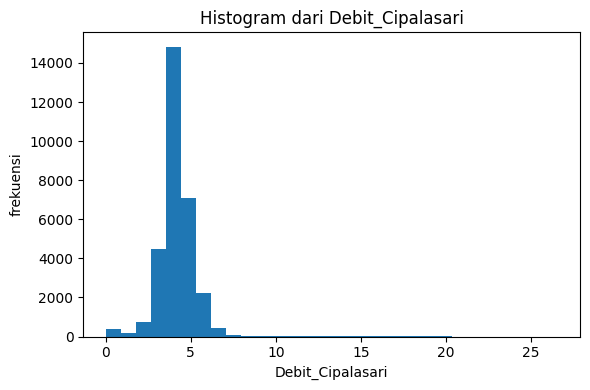

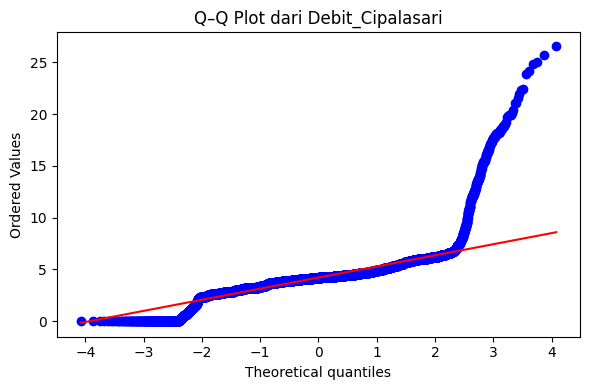

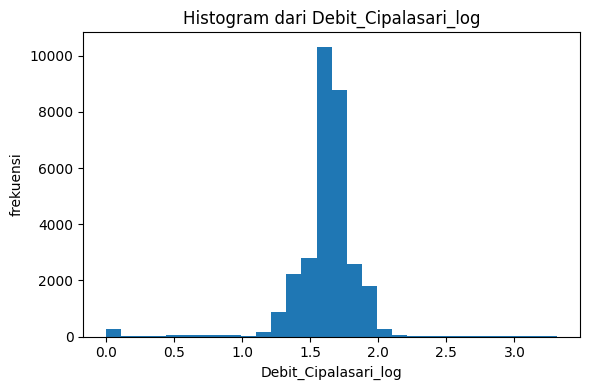

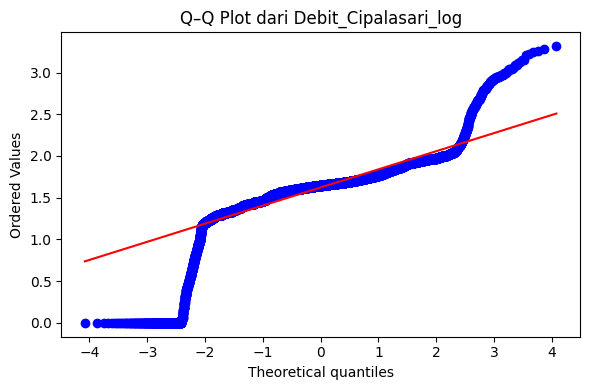

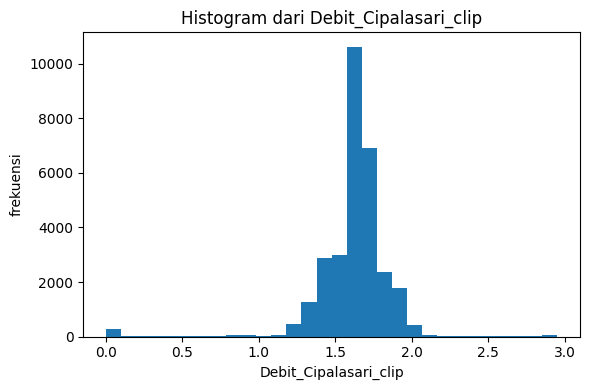

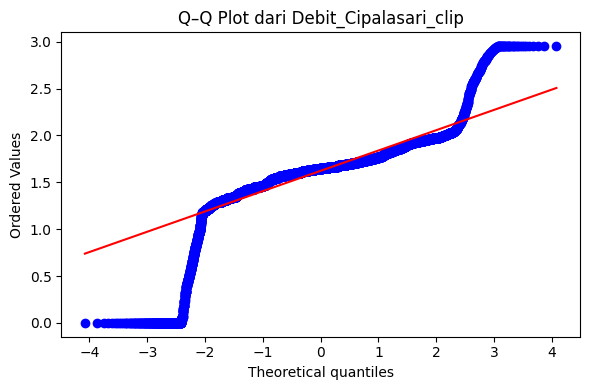

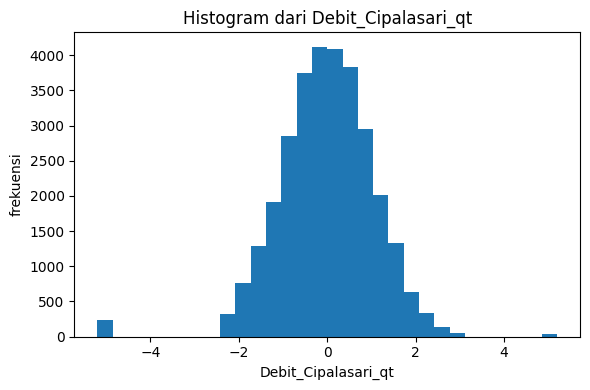

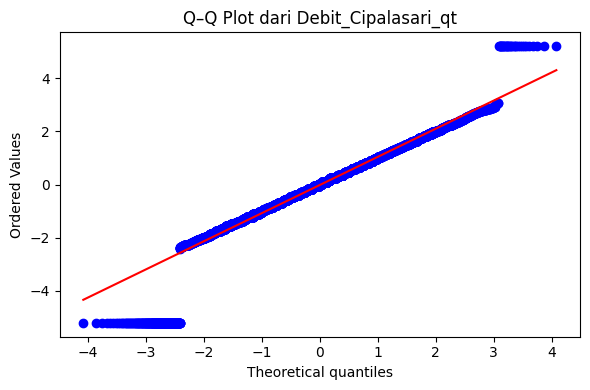

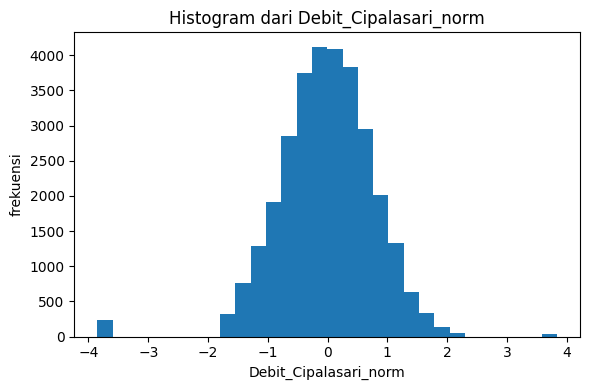

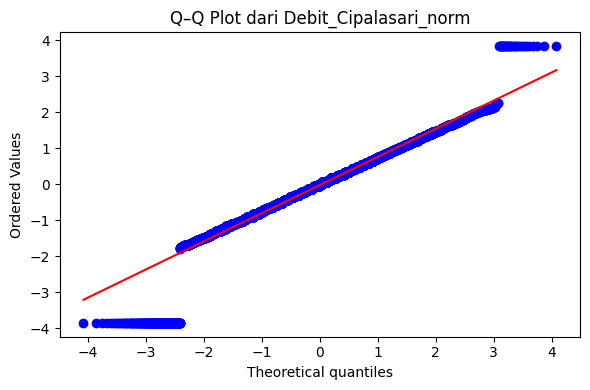

In [89]:

# 2. Definisikan kolom dan variannya
var = 'Debit_Cipalasari'
variants = [
    var,
    f'{var}_log',
    f'{var}_clip',
    f'{var}_qt',
    f'{var}_norm'
]

# 3. Hitung skewness, kurtosis, dan normality test
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram dari {col}')
    plt.xlabel(col); plt.ylabel('frekuensi')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot dari {col}')
    plt.tight_layout()
    plt.show()


            variant  skewness   kurtosis           test  p_value
0       Debit_Hilir  6.687787  46.186896  D’Agostino K²      0.0
1   Debit_Hilir_log  5.364799  30.363821  D’Agostino K²      0.0
2  Debit_Hilir_clip  5.362956  30.342660  D’Agostino K²      0.0
3    Debit_Hilir_qt -0.392824   2.677918  D’Agostino K²      0.0
4  Debit_Hilir_norm -0.392824   2.677918  D’Agostino K²      0.0


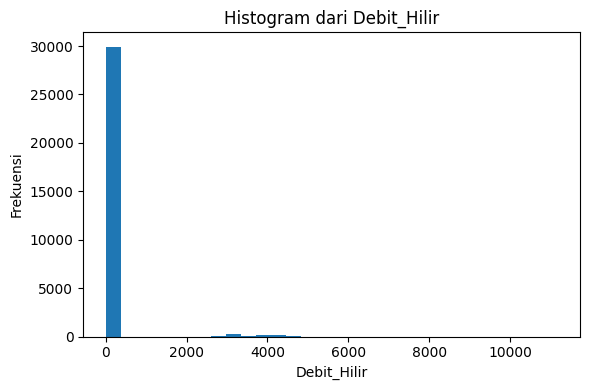

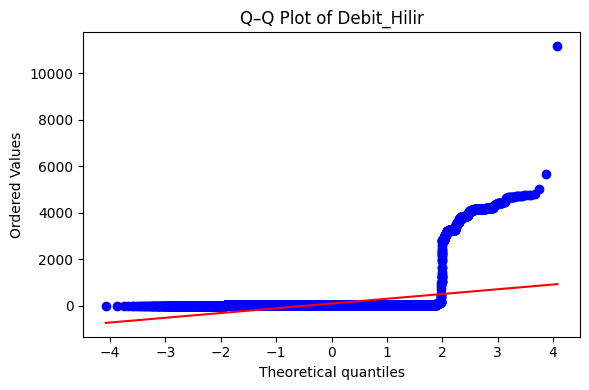

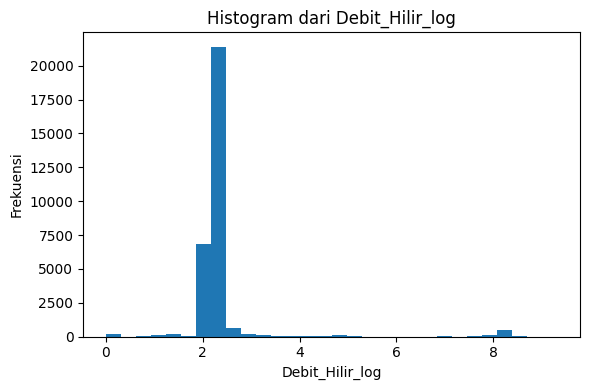

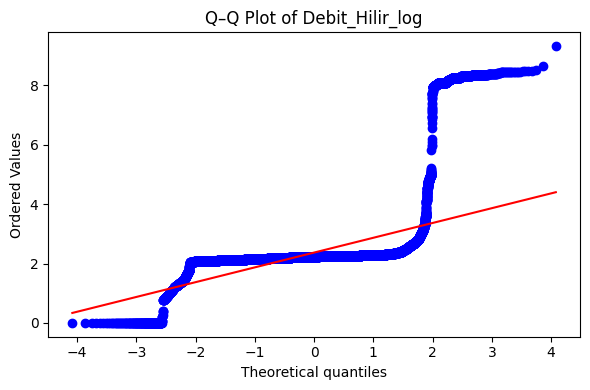

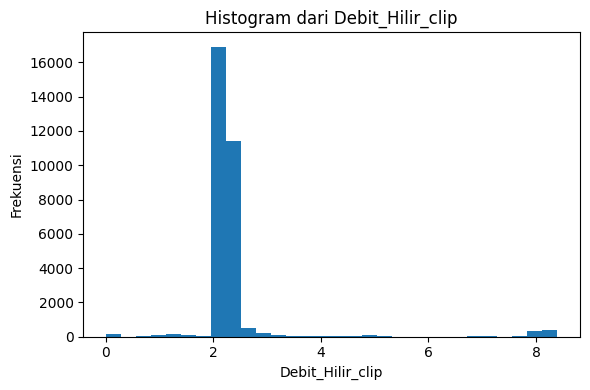

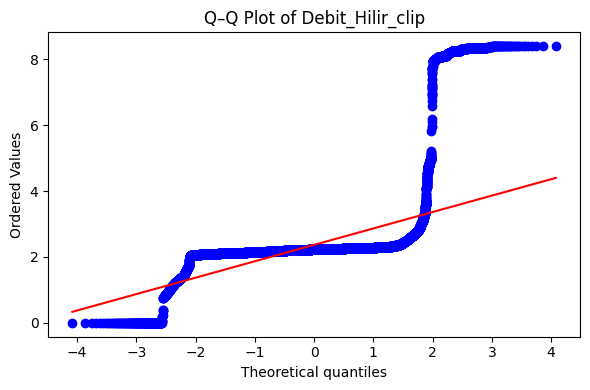

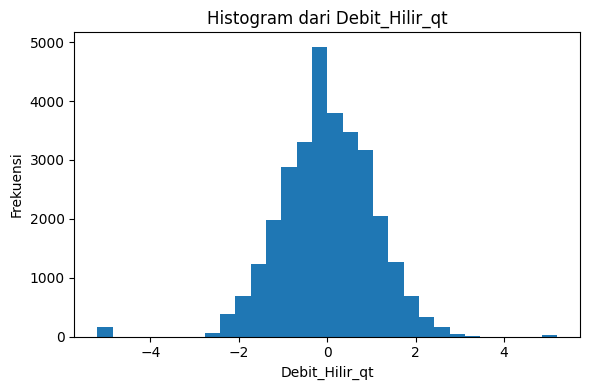

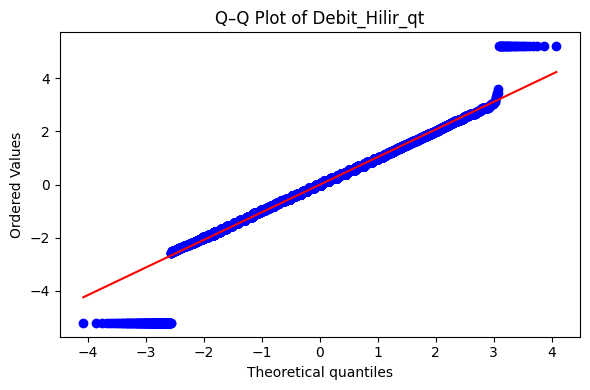

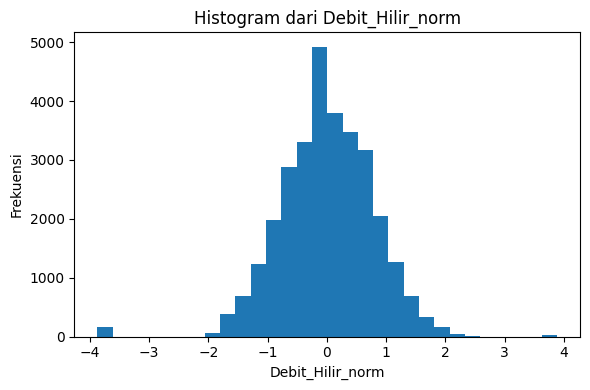

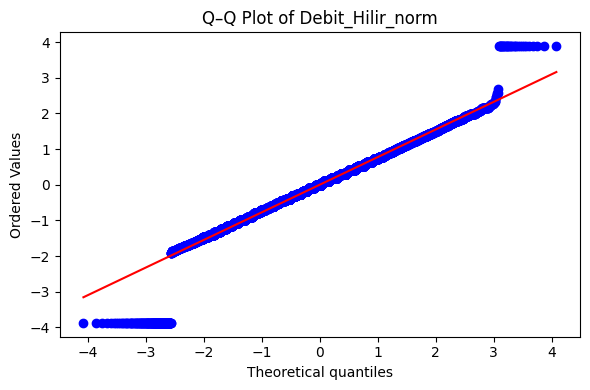

In [90]:

# 2. Definisikan kolom dan variannya
var = 'Debit_Hilir'
variants = [
    var,
    f'{var}_log',
    f'{var}_clip',
    f'{var}_qt',
    f'{var}_norm'
]

# 3. Hitung skewness, kurtosis, dan normality test
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram dari {col}')
    plt.xlabel(col); plt.ylabel('Frekuensi')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot of {col}')
    plt.tight_layout()
    plt.show()


           variant  skewness   kurtosis           test  p_value
0       Debit_Hulu  3.919454  16.828376  D’Agostino K²      0.0
1   Debit_Hulu_log  1.742888   5.437909  D’Agostino K²      0.0
2  Debit_Hulu_clip  1.736284   5.398702  D’Agostino K²      0.0
3    Debit_Hulu_qt -0.565199   3.228372  D’Agostino K²      0.0
4  Debit_Hulu_norm -0.565199   3.228372  D’Agostino K²      0.0


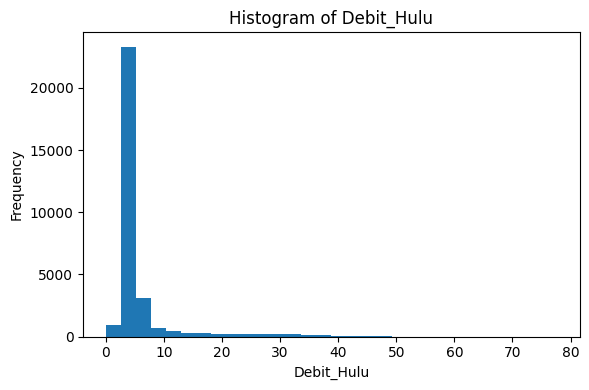

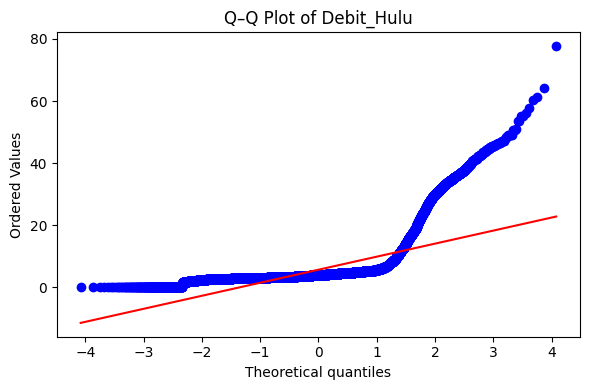

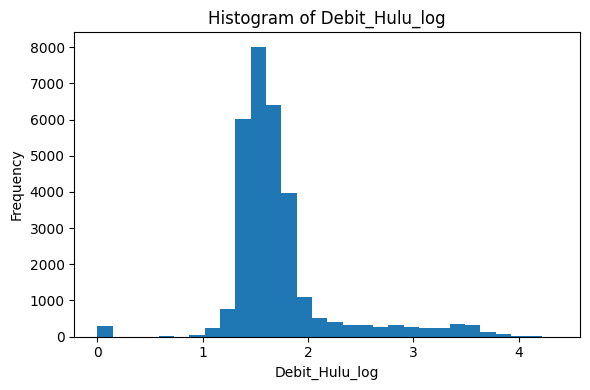

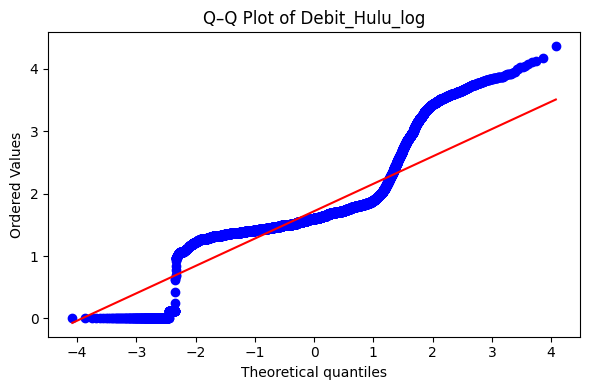

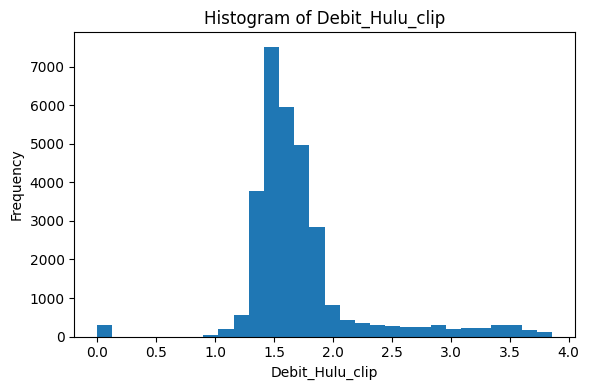

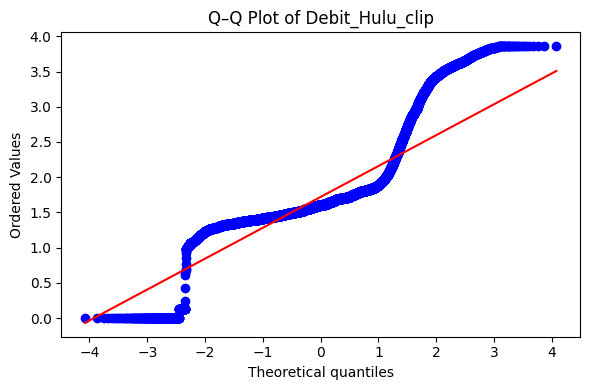

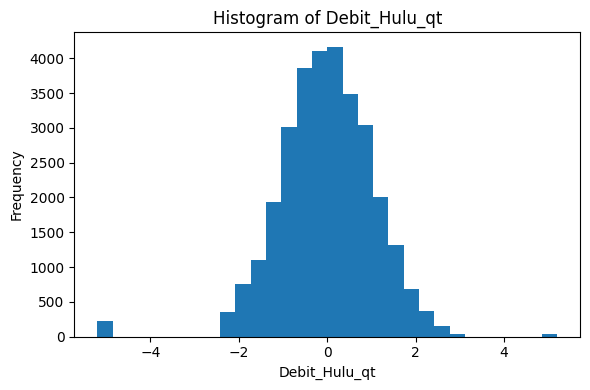

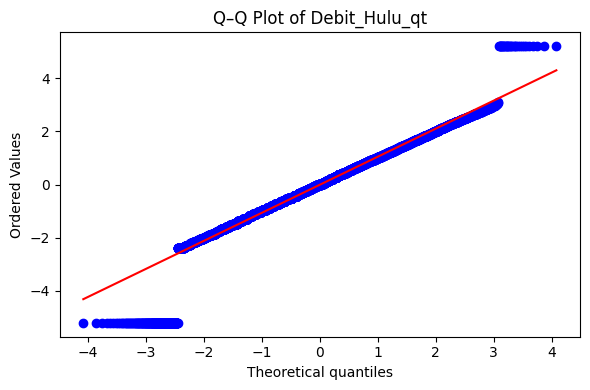

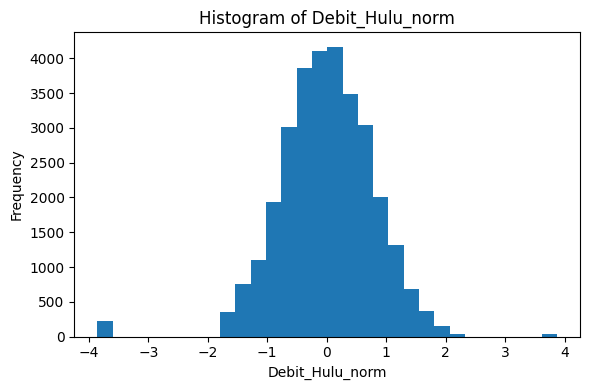

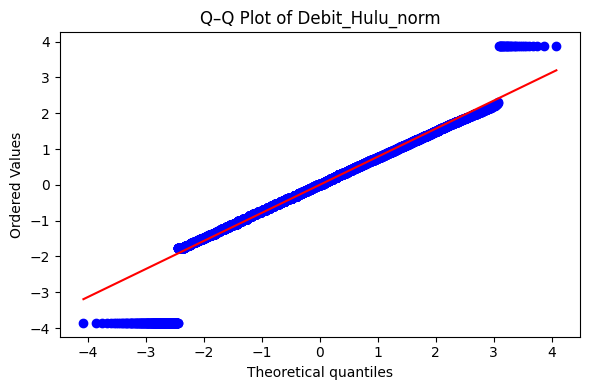

In [91]:

# 2. Definisikan kolom dan variannya
var = 'Debit_Hulu'
variants = [
    var,
    f'{var}_log',
    f'{var}_clip',
    f'{var}_qt',
    f'{var}_norm'
]

# 3. Hitung skewness, kurtosis, dan normality test
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot of {col}')
    plt.tight_layout()
    plt.show()


In [92]:
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,bojongsoang_clip,rain_flag_bojong,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.382560,0.382560,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.385541,0.385541,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.391598,0.391598,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.397618,0.397618,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.403602,0.403602,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2


In [93]:
rename_map = {
    'TMA_Cip_pt':   'TMA_Cipalasari_pt',
    'TMA_Cip_clip': 'TMA_Cipalasari_clip',
    'TMA_Cip_qt':   'TMA_Cipalasari_qt',
    'TMA_Cip_norm':'TMA_Cipalasari_norm',
    # dan seterusnya untuk TMA_Cit_* dan TMA_Kolam_*:
    'TMA_Cit_pt':   'TMA_Citarum_pt',
    'TMA_Cit_clip': 'TMA_Citarum_clip',
    'TMA_Cit_qt':   'TMA_Citarum_qt',
    'TMA_Cit_norm':'TMA_Citarum_norm',
}

df_copy.rename(columns=rename_map, inplace=True)
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,bojongsoang_clip,rain_flag_bojong,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.382560,0.382560,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.385541,0.385541,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.391598,0.391598,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.397618,0.397618,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.403602,0.403602,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2


In [94]:
df_copy['TMA_Cipalasari_log'] = np.log1p(df_copy['TMA_Cipalasari'])
df_copy['TMA_Citarum_log'] = np.log1p(df_copy['TMA_Citarum'])
df_copy['TMA_Kolam_log'] = np.log1p(df_copy['TMA_Kolam'])

df_copy.head()

d:\dummyML\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump,TMA_Cipalasari_log,TMA_Citarum_log,TMA_Kolam_log
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.382560,0.382560,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.491374,2.024164,2.630090
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.385541,0.385541,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.488523,2.022823,2.630046
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.391598,0.391598,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.482680,2.020080,2.629957
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.397618,0.397618,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.476802,2.017330,2.629867
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.403602,0.403602,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.470889,2.014572,2.629777


                varian  skewness   kurtosis            uji  p_value
0       TMA_Cipalasari  1.250574  13.473351  D’Agostino K²      0.0
1   TMA_Cipalasari_log  0.128894   6.497117  D’Agostino K²      0.0
2    TMA_Cipalasari_pt  0.499886  19.683905  D’Agostino K²      0.0
3  TMA_Cipalasari_norm  0.005161   5.402479  D’Agostino K²      0.0
4  TMA_Cipalasari_clip  2.388462   7.255902  D’Agostino K²      0.0
5    TMA_Cipalasari_qt  0.005161   5.402479  D’Agostino K²      0.0


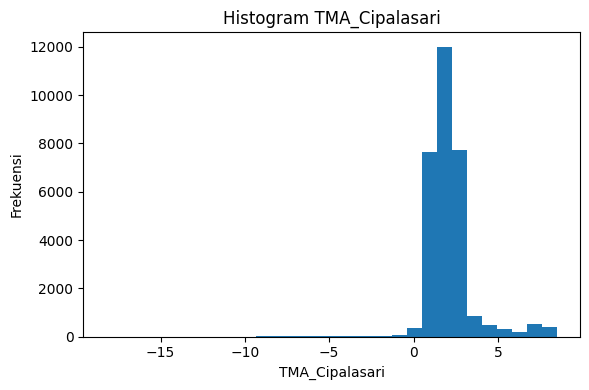

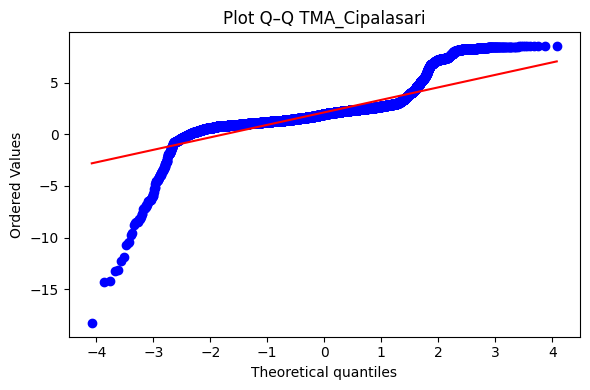

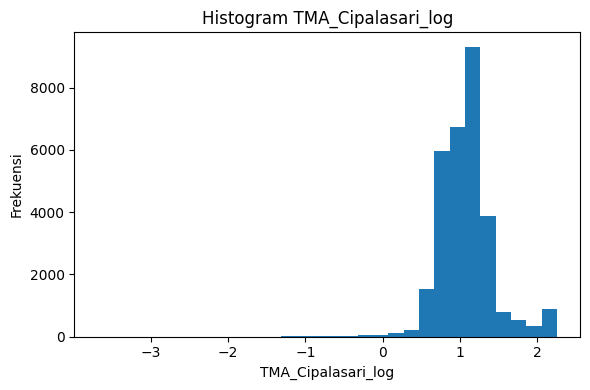

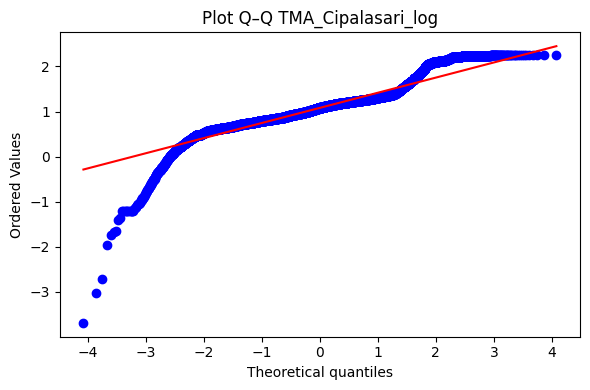

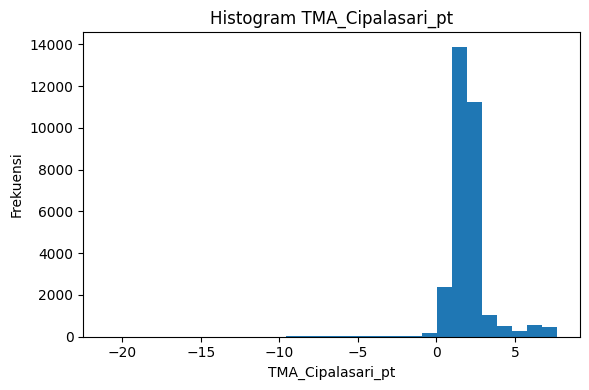

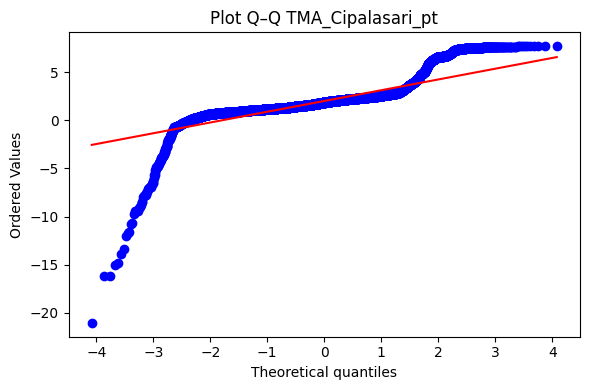

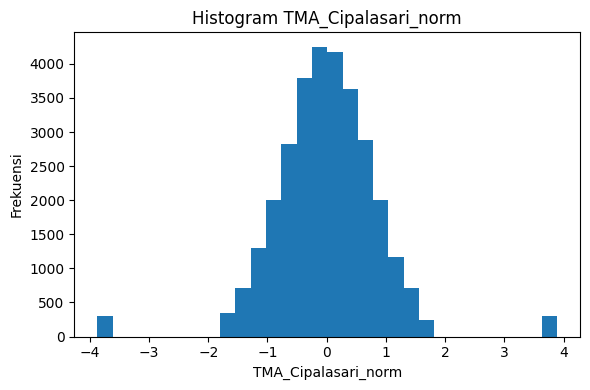

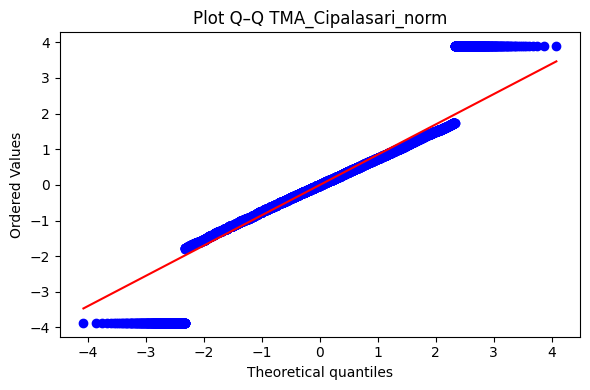

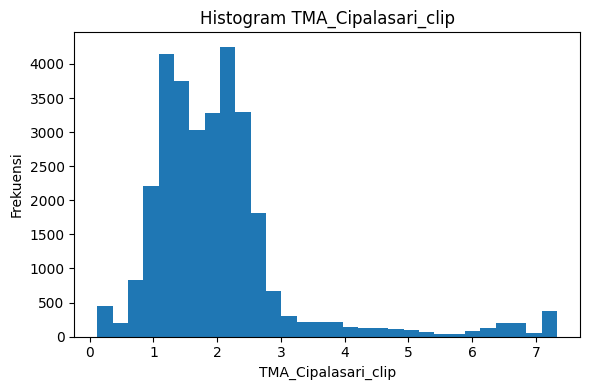

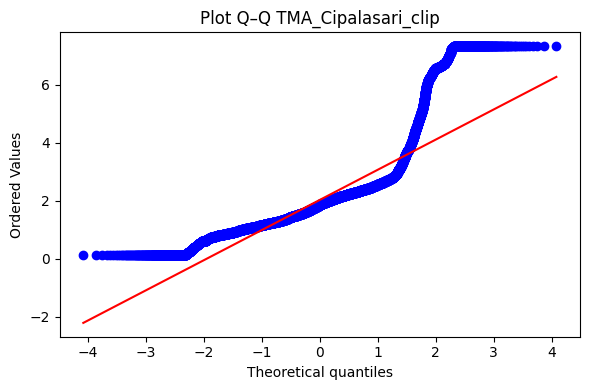

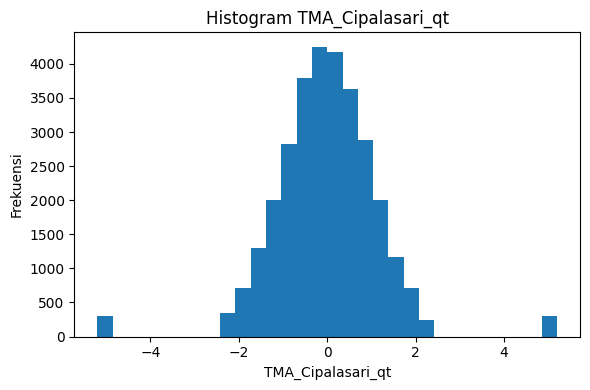

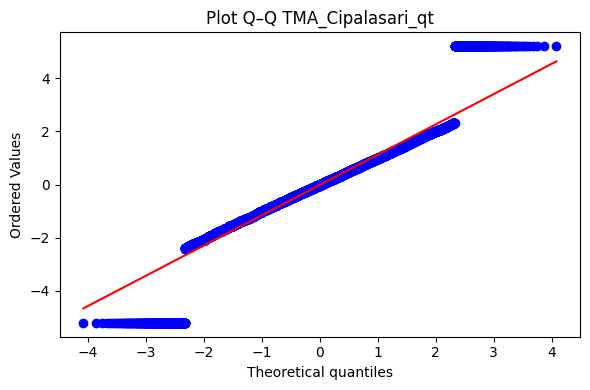

In [95]:
var = 'TMA_Cipalasari'
varian = [
    var,
    f'{var}_log',
    f'{var}_pt',
    f'{var}_norm',
    f'{var}_clip',
    f'{var}_qt'
]

# 3. Hitung skewness, kurtosis, dan uji normalitas tiap varian
hasil = []
for kol in varian:
    data = df_copy[kol].dropna()
    skew    = data.skew()
    kurt    = data.kurtosis()
    # Pilih jenis uji normalitas berdasarkan jumlah sampel
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        nama_uji = 'Shapiro–Wilk'
    else:
        stat, p = stats.normaltest(data)
        nama_uji = 'D’Agostino K²'
    hasil.append({
        'varian'    : kol,
        'skewness'  : skew,
        'kurtosis'  : kurt,
        'uji'       : nama_uji,
        'p_value'   : p
    })

# Hasil ringkasan dalam DataFrame
hasil_df = pd.DataFrame(hasil)
print(hasil_df)

# 4. Visualisasi histogram dan plot Q–Q untuk setiap varian
for kol in varian:
    data = df_copy[kol].dropna()

    # Histogram
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram {kol}')
    plt.xlabel(kol)
    plt.ylabel('Frekuensi')
    plt.tight_layout()
    plt.show()

    # Q–Q Plot
    plt.figure(figsize=(6,4))
    stats.probplot(data, dist='norm', plot=plt)
    plt.title(f'Plot Q–Q {kol}')
    plt.tight_layout()
    plt.show()

             varian  skewness  kurtosis            uji  p_value
0       TMA_Citarum -0.531134 -0.357602  D’Agostino K²      0.0
1   TMA_Citarum_log -1.350501  2.577848  D’Agostino K²      0.0
2    TMA_Citarum_pt -0.162335 -0.966450  D’Agostino K²      0.0
3  TMA_Citarum_norm  0.246350  5.743401  D’Agostino K²      0.0
4  TMA_Citarum_clip -0.152687 -1.005162  D’Agostino K²      0.0
5    TMA_Citarum_qt  0.246350  5.743401  D’Agostino K²      0.0


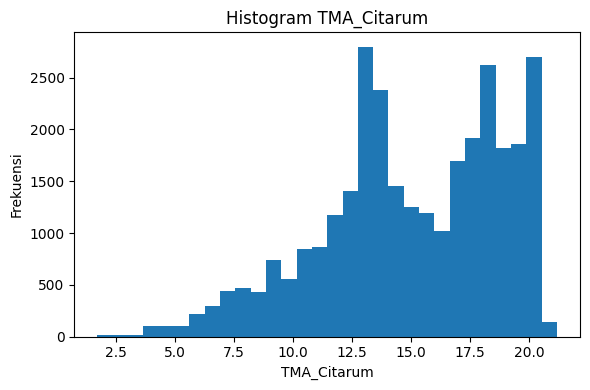

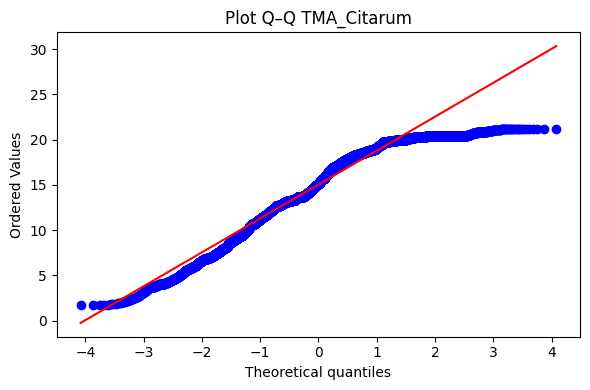

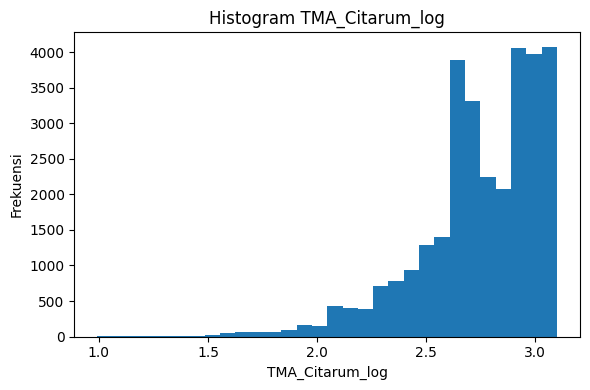

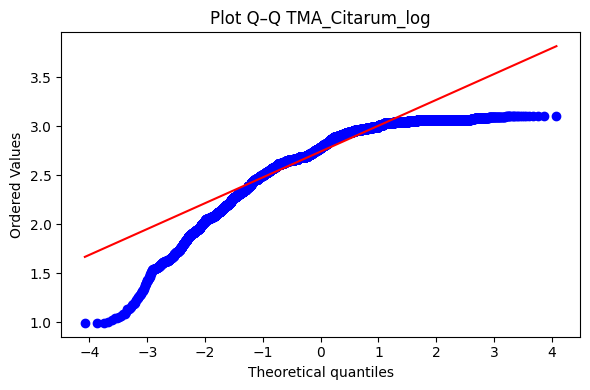

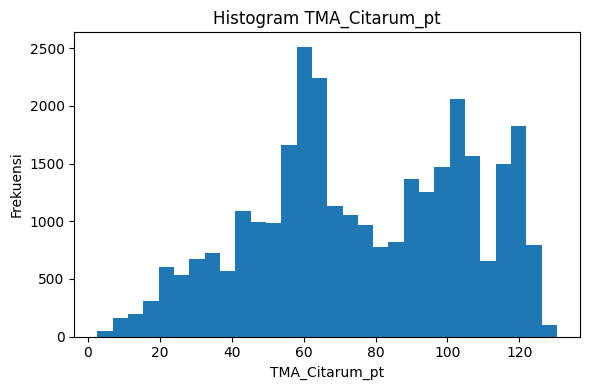

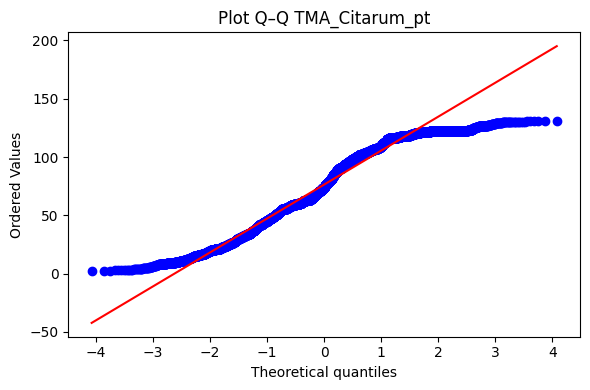

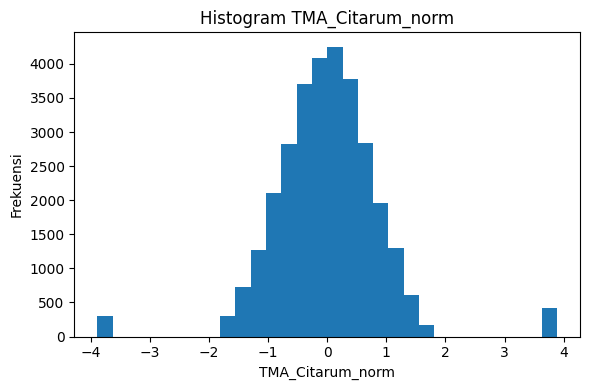

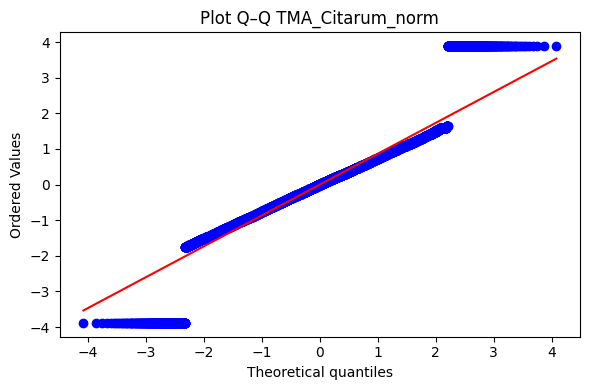

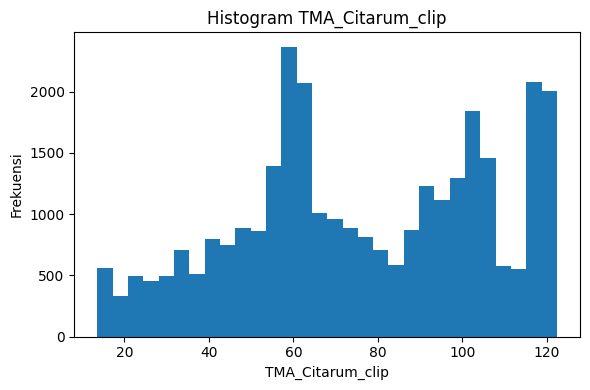

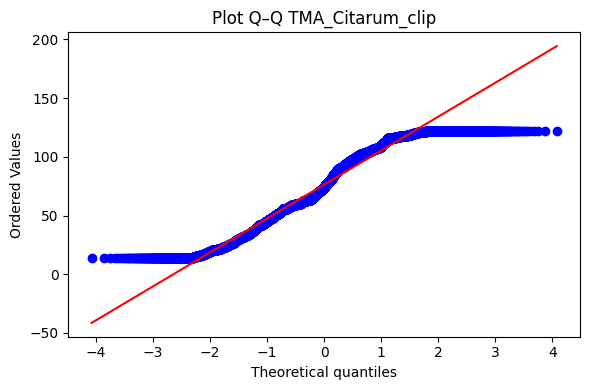

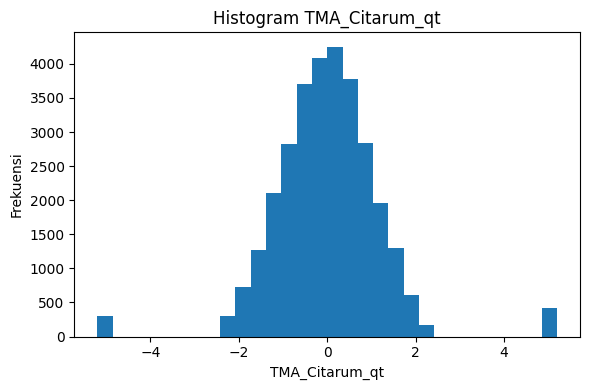

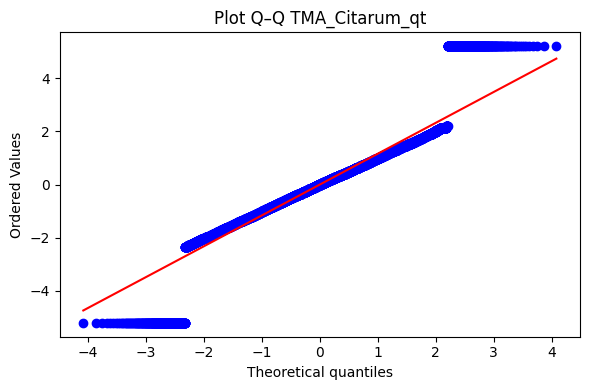

In [96]:
var = 'TMA_Citarum'
varian = [
    var,
    f'{var}_log',
    f'{var}_pt',
    f'{var}_norm',
    f'{var}_clip',
    f'{var}_qt'
]

# 3. Hitung skewness, kurtosis, dan uji normalitas tiap varian
hasil = []
for kol in varian:
    data = df_copy[kol].dropna()
    skew    = data.skew()
    kurt    = data.kurtosis()
    # Pilih jenis uji normalitas berdasarkan jumlah sampel
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        nama_uji = 'Shapiro–Wilk'
    else:
        stat, p = stats.normaltest(data)
        nama_uji = 'D’Agostino K²'
    hasil.append({
        'varian'    : kol,
        'skewness'  : skew,
        'kurtosis'  : kurt,
        'uji'       : nama_uji,
        'p_value'   : p
    })

# Hasil ringkasan dalam DataFrame
hasil_df = pd.DataFrame(hasil)
print(hasil_df)

# 4. Visualisasi histogram dan plot Q–Q untuk setiap varian
for kol in varian:
    data = df_copy[kol].dropna()

    # Histogram
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram {kol}')
    plt.xlabel(kol)
    plt.ylabel('Frekuensi')
    plt.tight_layout()
    plt.show()

    # Q–Q Plot
    plt.figure(figsize=(6,4))
    stats.probplot(data, dist='norm', plot=plt)
    plt.title(f'Plot Q–Q {kol}')
    plt.tight_layout()
    plt.show()

           varian  skewness  kurtosis            uji  p_value
0       TMA_Kolam  0.241099 -1.478000  D’Agostino K²      0.0
1   TMA_Kolam_log -0.160463 -1.651184  D’Agostino K²      0.0
2    TMA_Kolam_pt -0.085123 -1.654087  D’Agostino K²      0.0
3  TMA_Kolam_norm -0.076636  5.672046  D’Agostino K²      0.0
4  TMA_Kolam_clip -0.086354 -1.656178  D’Agostino K²      0.0
5    TMA_Kolam_qt -0.076636  5.672046  D’Agostino K²      0.0


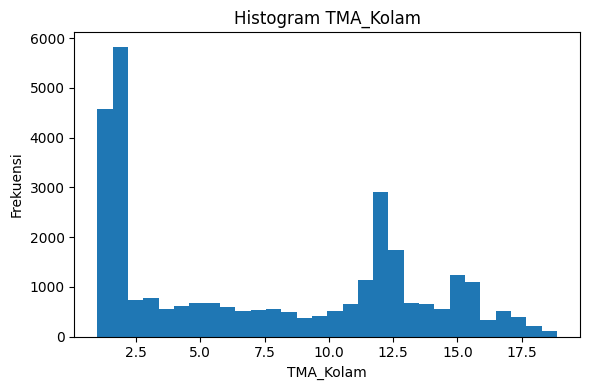

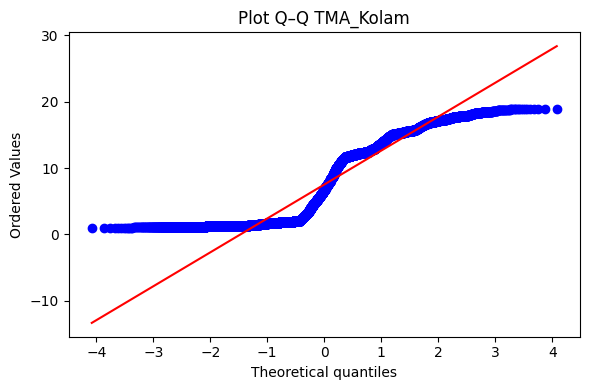

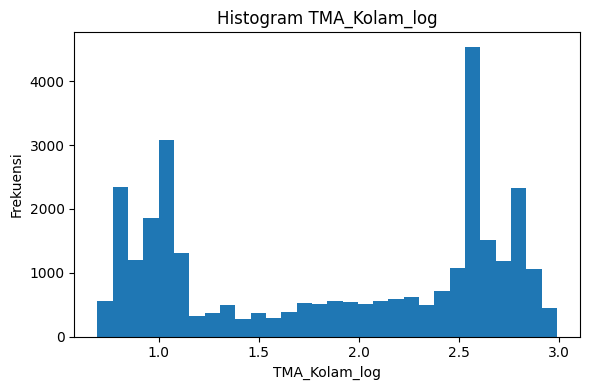

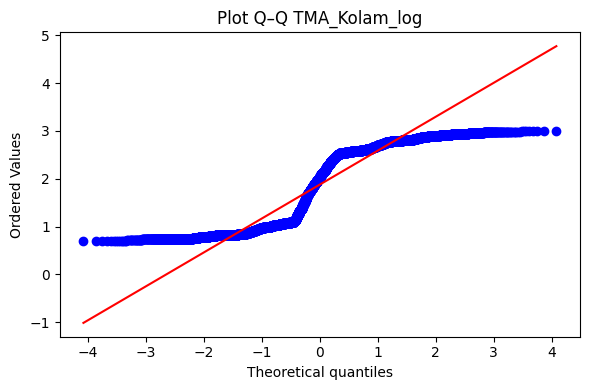

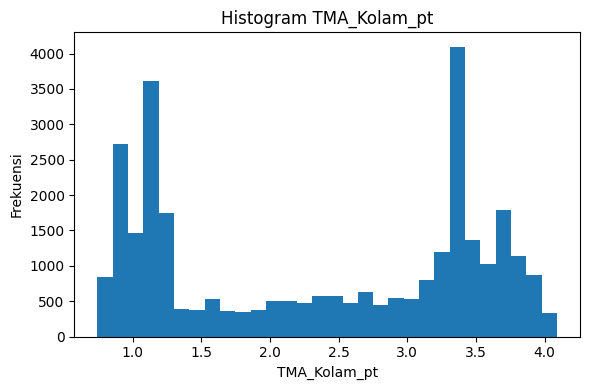

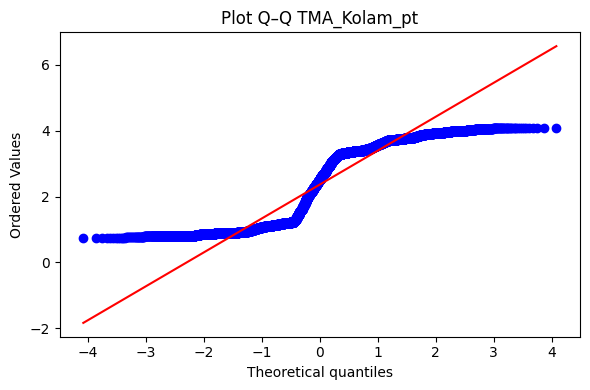

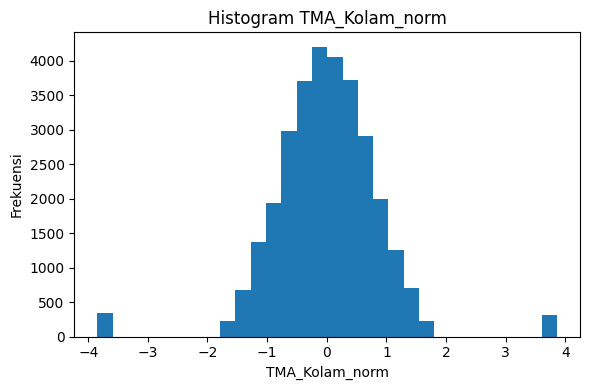

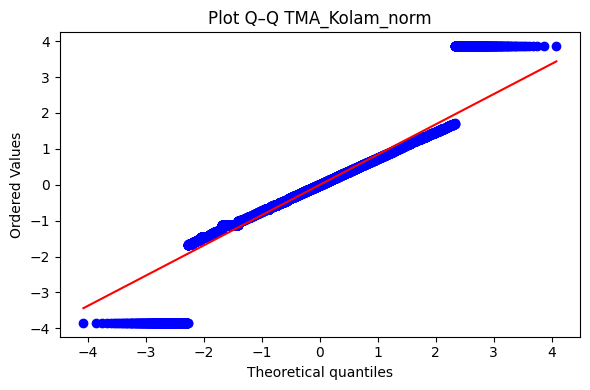

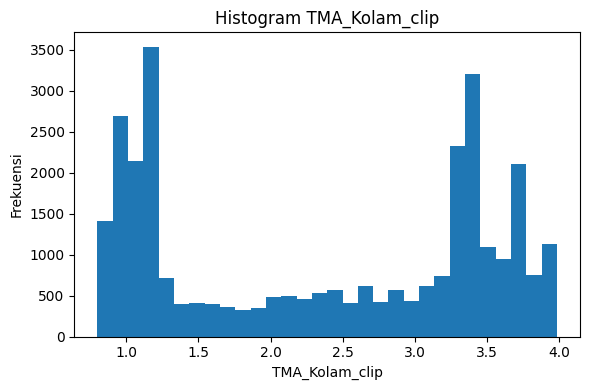

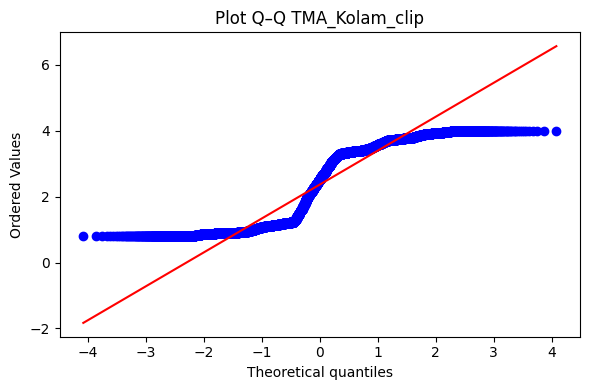

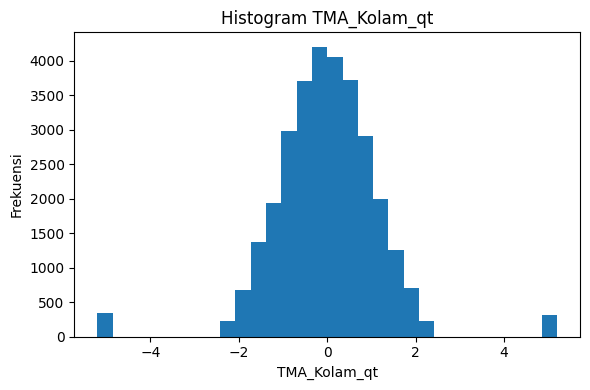

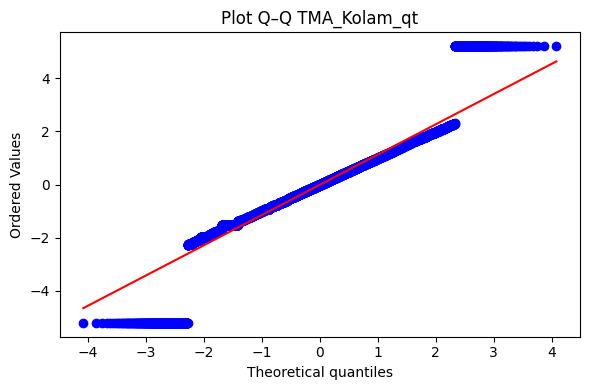

In [97]:
var = 'TMA_Kolam'
varian = [
    var,
    f'{var}_log',
    f'{var}_pt',
    f'{var}_norm',
    f'{var}_clip',
    f'{var}_qt'
]

# 3. Hitung skewness, kurtosis, dan uji normalitas tiap varian
hasil = []
for kol in varian:
    data = df_copy[kol].dropna()
    skew    = data.skew()
    kurt    = data.kurtosis()
    # Pilih jenis uji normalitas berdasarkan jumlah sampel
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        nama_uji = 'Shapiro–Wilk'
    else:
        stat, p = stats.normaltest(data)
        nama_uji = 'D’Agostino K²'
    hasil.append({
        'varian'    : kol,
        'skewness'  : skew,
        'kurtosis'  : kurt,
        'uji'       : nama_uji,
        'p_value'   : p
    })

# Hasil ringkasan dalam DataFrame
hasil_df = pd.DataFrame(hasil)
print(hasil_df)

# 4. Visualisasi histogram dan plot Q–Q untuk setiap varian
for kol in varian:
    data = df_copy[kol].dropna()

    # Histogram
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram {kol}')
    plt.xlabel(kol)
    plt.ylabel('Frekuensi')
    plt.tight_layout()
    plt.show()

    # Q–Q Plot
    plt.figure(figsize=(6,4))
    stats.probplot(data, dist='norm', plot=plt)
    plt.title(f'Plot Q–Q {kol}')
    plt.tight_layout()
    plt.show()

In [98]:
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump,TMA_Cipalasari_log,TMA_Citarum_log,TMA_Kolam_log
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.382560,0.382560,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.491374,2.024164,2.630090
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.385541,0.385541,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.488523,2.022823,2.630046
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.391598,0.391598,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.482680,2.020080,2.629957
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.397618,0.397618,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.476802,2.017330,2.629867
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.403602,0.403602,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.470889,2.014572,2.629777


            variant  skewness  kurtosis           test        p_value
0   dayeuhkolot_log  2.090384  2.687338  D’Agostino K²   0.000000e+00
1  dayeuhkolot_norm -0.084631 -0.481393  D’Agostino K²  1.379437e-123
2  dayeuhkolot_clip  2.090384  2.687338  D’Agostino K²   0.000000e+00
3    dayeuhkolot_qt -0.084631 -0.481393  D’Agostino K²  1.379437e-123


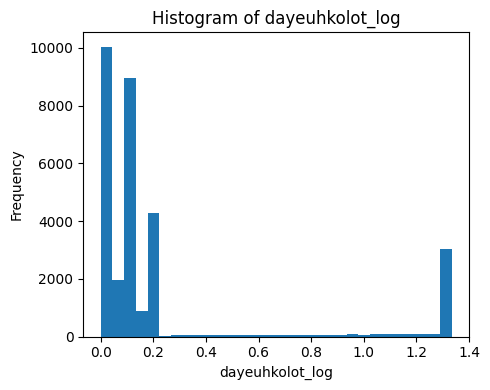

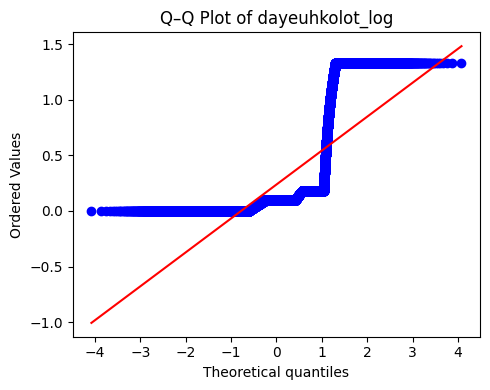

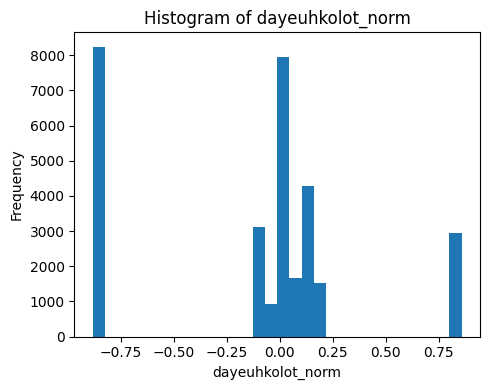

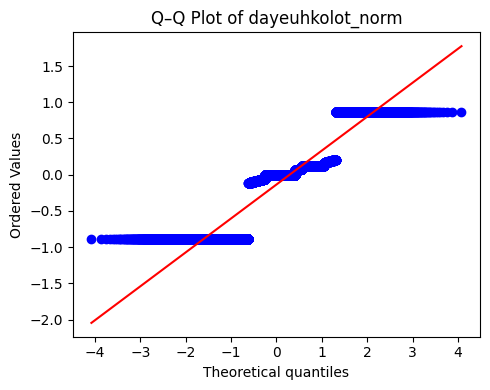

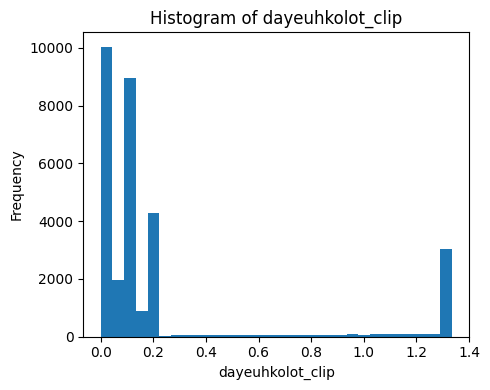

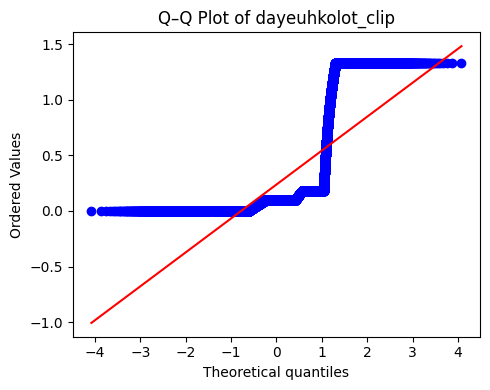

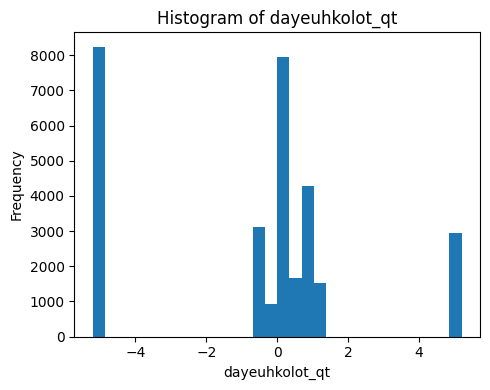

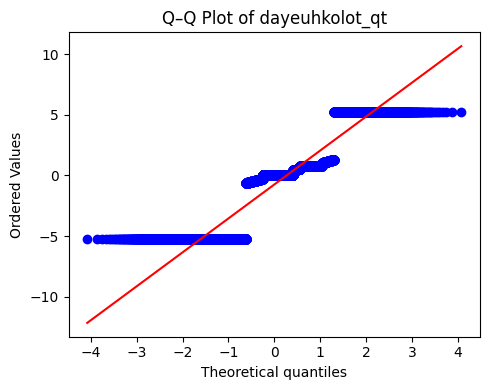

In [99]:
# 2. Pilih variants khusus untuk TMA_Cipalasari
var = 'dayeuhkolot'
variants = [
    # f'{var}_pt',
    f'{var}_log',
    f'{var}_norm',
    f'{var}_clip',
    f'{var}_qt'
]

# 3. Hitung skewness, kurtosis, dan normality test untuk tiap variant
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        _, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        _, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()

    plt.figure(figsize=(5,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot of {col}')
    plt.tight_layout()
    plt.show()


            variant  skewness  kurtosis           test        p_value
0   bojongsoang_log  2.061792  2.627861  D’Agostino K²   0.000000e+00
1  bojongsoang_norm -0.081949 -0.477180  D’Agostino K²  2.186699e-120
2  bojongsoang_clip  2.061792  2.627861  D’Agostino K²   0.000000e+00
3    bojongsoang_qt -0.081949 -0.477180  D’Agostino K²  2.186699e-120


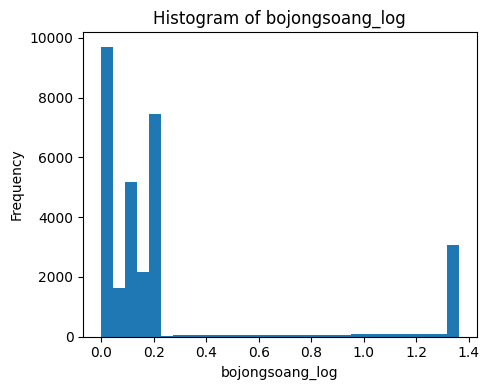

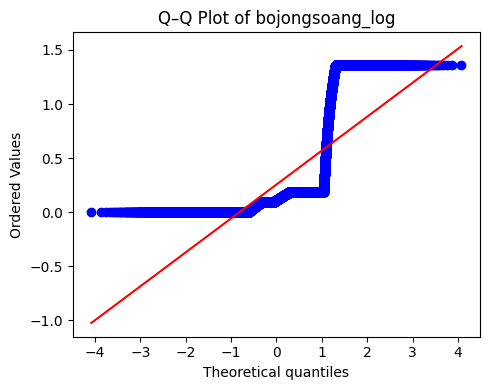

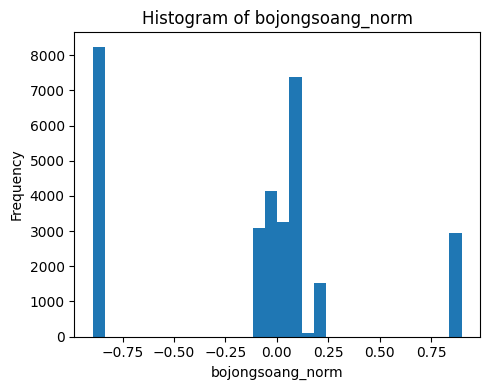

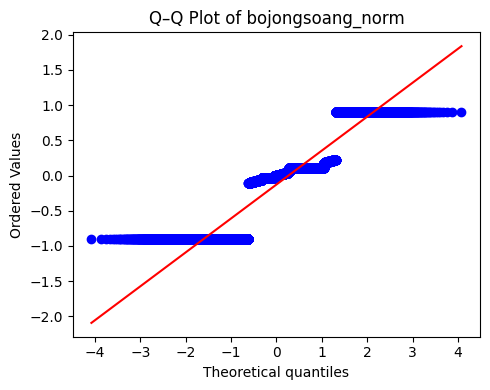

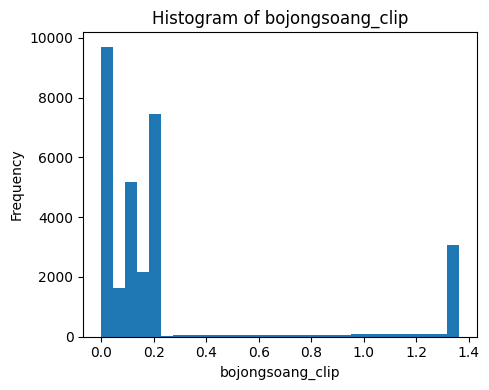

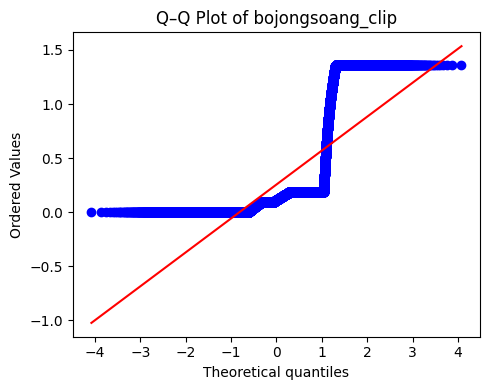

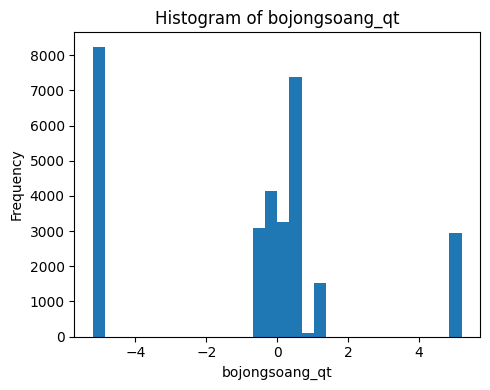

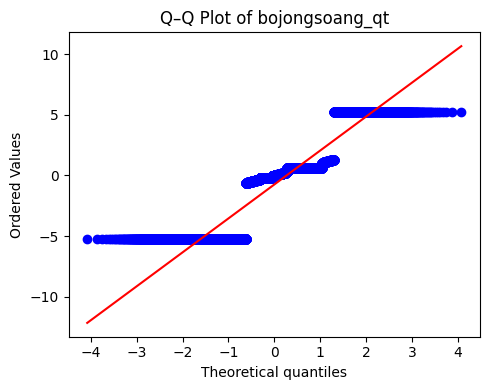

In [100]:
# 2. Pilih variants khusus untuk TMA_Cipalasari
var = 'bojongsoang'
variants = [
    # f'{var}_pt',
    f'{var}_log',
    f'{var}_norm',
    f'{var}_clip',
    f'{var}_qt'
]

# 3. Hitung skewness, kurtosis, dan normality test untuk tiap variant
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        _, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        _, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()

    plt.figure(figsize=(5,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot of {col}')
    plt.tight_layout()
    plt.show()


In [101]:
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump,TMA_Cipalasari_log,TMA_Citarum_log,TMA_Kolam_log
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.382560,0.382560,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.491374,2.024164,2.630090
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.385541,0.385541,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.488523,2.022823,2.630046
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.391598,0.391598,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.482680,2.020080,2.629957
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.397618,0.397618,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.476802,2.017330,2.629867
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.403602,0.403602,...,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,0.470889,2.014572,2.629777


In [ ]:
import joblib

def recommend_pump(tma_cm):
    if tma_cm < 3.2:
        return 0  # Aman
    elif tma_cm <= 9.6:
        return 1  # Siaga1
    elif tma_cm <= 14:
        return 2  # Siaga2
    else:
        return 3  # Siaga3+

df_copy['pump_recommendation'] = df_copy['TMA_Kolam'].apply(recommend_pump)

# 4. Gunakan kolom status_banjir yang sudah ada di dataset sebagai target
#    (jangan overwrite dengan pump_recommendation)
#    Pastikan df['status_banjir'] sudah tersedia: 0=aman,1=siaga1,2=siaga2,3=siaga3

# 5. Definisikan fitur dan target
feature_cols = [
    'Debit_Cipalasari_norm',
    'Debit_Hilir_norm',
    'Debit_Hulu_norm',
    'TMA_Cipalasari_norm',
    'TMA_Citarum_norm',
    'TMA_Kolam_norm',
]
X = df_copy[feature_cols]
y = df_copy['status_banjir'] =  df_copy['pump_recommendation']

# 6. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 7. Inisialisasi model-model yang akan dibandingkan
models = {
    # 'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    # 'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    # 'LogisticRegression': LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42),
    # 'SupportVectorMachine': SVC(probability=True, random_state=42)

}

# 8. Latih, prediksi, dan evaluasi tiap model
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    })

    joblib.dump(model, f'D:\dummyML\data\DT_model.pkl')
    print(f"Model '{name}' berhasil diekspor ke '/mnt/data/{name}_model.pkl'")

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df)

Model 'DecisionTree' berhasil diekspor ke '/mnt/data/DecisionTree_model.pkl'
          Model  Accuracy  F1 (weighted)       MAE      RMSE
0  DecisionTree  0.999674       0.999674  0.000326  0.018062


<>:59: SyntaxWarning: invalid escape sequence '\d'
<>:59: SyntaxWarning: invalid escape sequence '\d'
C:\Users\UsHER\AppData\Local\Temp\ipykernel_8528\1178645403.py:59: SyntaxWarning: invalid escape sequence '\d'
  joblib.dump(model, f'D:\dummyML\data\DT_model.pkl')


In [103]:
df_copy.tail()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump,TMA_Cipalasari_log,TMA_Citarum_log,TMA_Kolam_log,pump_recommendation,status_banjir
30647,0.0,7.72441,0.1344,0.63,12.68,10.35,0.0,0.0,0.0,0.0,...,0.0,0,-5.199338,-0.881862,2,0.48858,2.615935,2.429218,2,2
30648,0.0,7.72441,0.1344,0.63,12.68,10.35,0.0,0.0,0.0,0.0,...,0.0,0,-5.199338,-0.881862,2,0.48858,2.615935,2.429218,2,2
30649,0.0,7.72441,0.1344,0.63,12.68,10.35,0.0,0.0,0.0,0.0,...,0.0,0,-5.199338,-0.881862,2,0.48858,2.615935,2.429218,2,2
30650,0.0,7.72441,0.1344,0.63,12.68,10.35,0.0,0.0,0.0,0.0,...,0.0,0,-5.199338,-0.881862,2,0.48858,2.615935,2.429218,2,2
30651,0.0,7.72441,0.1344,0.63,12.68,10.35,0.0,0.0,0.0,0.0,...,0.0,0,-5.199338,-0.881862,2,0.48858,2.615935,2.429218,2,2


<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
C:\Users\UsHER\AppData\Local\Temp\ipykernel_8528\4234292870.py:6: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv('D:\dummyML\data\polder_data_fix.csv')  # Ganti dengan path file data latih Anda
C:\Users\UsHER\AppData\Local\Temp\ipykernel_8528\4234292870.py:19: SyntaxWarning: invalid escape sequence '\d'
  joblib.dump(dt, 'D:\dummyML\data\decision_tree_model.pkl')
C:\Users\UsHER\AppData\Local\Temp\ipykernel_8528\4234292870.py:6: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv('D:\dummyML\data\polder_data_fix.csv')  # Ganti dengan path file data latih Anda
C:\Users\UsHER\AppData\Local\Temp\ipykernel_8528\4234292870.py:19: SyntaxWarning: invalid escape sequence '\d'
  joblib.dump(dt, 'D:\dummyML\data\decision_tree_model.pkl')


KeyError: "['label'] not found in axis"